In [25]:
!pip install patsy bambi


In [26]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import multipletests
from patsy import dmatrices
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# READ DATA

In [27]:
# --------------------------------------------------
# 0. Paths and output dir
# --------------------------------------------------
EOP_PATH        = "eop_raw_values.csv"
AMR_GENES_PATH  = "amrfinderplus_all.tsv"
DEFENSE_PATH    = "TableS3-defenseSystems.xlsx"
AMR_PHENO       = "amrresults.csv"
PHAGE_GENES_PATH= "Phage_tail_clusters_WClusterID.tsv"
# PHAGE_GENES_PATH= "Phage_gene_matrix.csv"

# os.makedirs(OUTDIR, exist_ok=True)

# --------------------------------------------------
# 1. Helper functions
# --------------------------------------------------
def canon_host(name: str) -> str:
    """
    Normalize host names across tables.
    Examples:
      'A xylosoxidans jini'  -> 'A xylosoxidans jini'
      'A. xylosoxidans jini' -> 'A xylosoxidans jini'
    """
    if pd.isna(name):
        return np.nan
    s = str(name).strip()
    # remove "A." vs "A "
    s = s.replace("A. ", "A ")
    s = s.replace("A.", "A ")
    s = s.replace(".", "")
    # collapse whitespace
    s = " ".join(s.split())
    return s

def host_id_from_canon(canon: str) -> str:
    if pd.isna(canon):
        return np.nan
    return canon.lower().replace(" ", "_")

def host_species_from_canon(canon: str) -> str:
    """Assume 'A xylosoxidans jini' -> species 'xylosoxidans'."""
    if pd.isna(canon):
        return np.nan
    parts = canon.split()
    return parts[1] if len(parts) >= 2 else np.nan

def canon_phage(name: str) -> str:
    if pd.isna(name):
        return np.nan
    return str(name).strip().lower()

def logit(x):
    x = np.clip(x, 1e-9, 1 - 1e-9)
    return np.log(x / (1 - x))

def scale_safely(x: pd.Series) -> pd.Series:
    if not np.issubdtype(x.dtype, np.number):
        return x
    m = np.nanmean(x)
    s = np.nanstd(x, ddof=1)
    if s == 0 or np.isnan(s):
        return pd.Series(0.0, index=x.index)
    return (x - m) / s


In [28]:

# --------------------------------------------------
# 2. Load and reshape EOP table (phage × host -> long)
# --------------------------------------------------
eop_wide = pd.read_csv(EOP_PATH)

# EOP column = phage name
eop_long = eop_wide.melt(
    id_vars=["EOP"],
    var_name="host_raw",
    value_name="EOP_value"
)

# rename phage column and normalise
eop_long = eop_long.rename(columns={"EOP": "phage_raw"})
eop_long["phage_id"] = eop_long["phage_raw"].apply(canon_phage)

# host naming and species
eop_long["host_canon"]   = eop_long["host_raw"].apply(canon_host)
eop_long['bacteria']      = eop_long['host_raw']
eop_long["host_id"]      = eop_long["host_canon"].apply(host_id_from_canon)
eop_long["host_species"] = eop_long["host_canon"].apply(host_species_from_canon)

# EOP numeric
eop_long["EOP_value"] = pd.to_numeric(eop_long["EOP_value"], errors="coerce")
eop_long

,phage_raw,host_raw,EOP_value,phage_id,host_canon,bacteria,host_id,host_species
0,Coliflower,A xylosoxidans jini,1.780000e+01,coliflower,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
1,Infector,A xylosoxidans jini,2.500000e-01,infector,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
2,Yaccob,A xylosoxidans jini,3.750000e-04,yaccob,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
3,Rage,A xylosoxidans jini,7.690000e-08,rage,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
4,Patchman,A xylosoxidans jini,6.150000e-07,patchman,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
...,...,...,...,...,...,...,...,...
100,ewik,A insolitus cram,2.500000e-06,ewik,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus
101,maay,A insolitus cram,2.000000e-02,maay,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus
102,shaaii,A insolitus cram,5.830000e-05,shaaii,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus
103,nyashin,A insolitus cram,2.670000e-03,nyashin,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus


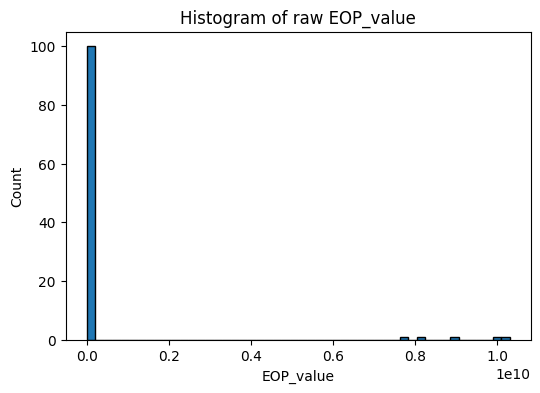

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(eop_long["EOP_value"], bins=50, edgecolor="black")
plt.xlabel("EOP_value")
plt.ylabel("Count")
plt.title("Histogram of raw EOP_value")
plt.show()

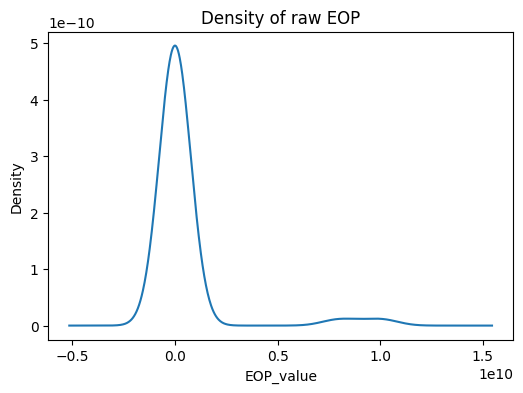

In [30]:
eop_long["EOP_value"].plot(kind="density", figsize=(6,4), title="Density of raw EOP")
plt.xlabel("EOP_value")
plt.show()

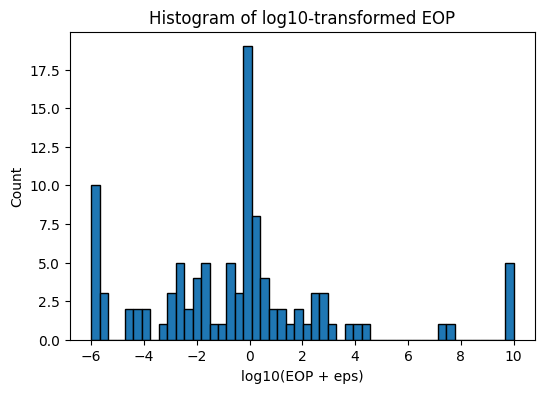

In [31]:
import numpy as np

eps = 1e-6
eop_long["log_EOP"] = np.log10(eop_long["EOP_value"] + eps)
plt.figure(figsize=(6,4))
plt.hist(eop_long["log_EOP"], bins=50, edgecolor="black")
plt.xlabel("log10(EOP + eps)")
plt.ylabel("Count")
plt.title("Histogram of log10-transformed EOP")
plt.show()

In [32]:
# --------------------------------------------------
# 3. Defence systems per host (TableS3-defenseSystems.xlsx)
# --------------------------------------------------
def_df = pd.read_excel(DEFENSE_PATH)

# normalise host names
def_df["host_canon"] = def_df["bacteria"].apply(canon_host)
def_df["host_id"]    = def_df["host_canon"].apply(host_id_from_canon)

# focus on defence systems
def_df["genes_count"] = pd.to_numeric(def_df["genes_count"], errors="coerce").fillna(0)

def_df_melted = (
    def_df
    .groupby(["bacteria", "subtype"])["genes_count"]
    .sum()
    .reset_index(name="count")
)
def_df_melted


,bacteria,subtype,count
0,A. insolitus aura,CBASS_III,5
1,A. insolitus aura,Kiwa,2
2,A. insolitus aura,RM_Type_II,2
3,A. insolitus aura,Shedu,1
4,A. insolitus cram,CBASS_III,5
5,A. insolitus cram,Kiwa,3
6,A. insolitus neet,CBASS_II,4
7,A. insolitus neet,CBASS_III,5
8,A. insolitus neet,Kiwa,2
9,A. insolitus neet,Shedu,1


In [33]:
# --------------------------------------------------
# 4. AMR gene counts per host (amrfinderplus_all.tsv)
# --------------------------------------------------
amr = pd.read_csv(AMR_GENES_PATH, sep="\t")

amr["bacteria"] = amr["sample"]

# count by Class (BETA-LACTAM, AMINOGLYCOSIDE, TETRACYCLINE, etc.)
amr_class_counts = (
    amr.groupby(["bacteria", "Subclass"])["Protein id"]
    .nunique()
    .unstack("Subclass", fill_value=0)
)

amr_class_counts["AMR_counts"] = amr_class_counts.sum(axis=1)
amr_class_counts = amr_class_counts.reset_index()
#amr_class_counts
amr_class_counts_melt = amr_class_counts.melt(
    id_vars=["bacteria"],
    var_name="AMR_class",
    value_name="count"
)
amr_class_counts_melt
amr_class_counts_melt = amr_class_counts_melt[~amr_class_counts_melt['AMR_class'].str.contains('AMR_counts', na=False)]
amr_class_counts_melt

,bacteria,AMR_class,count
0,A. insolitus aura,AMINOGLYCOSIDE,2
1,A. insolitus cram,AMINOGLYCOSIDE,2
2,A. insolitus neet,AMINOGLYCOSIDE,1
3,A. insolitus vya,AMINOGLYCOSIDE,0
4,A. xylosoxidans ayb,AMINOGLYCOSIDE,0
5,A. xylosoxidans jini,AMINOGLYCOSIDE,1
6,A. xylosoxidans suz,AMINOGLYCOSIDE,1
7,A. insolitus aura,BETA-LACTAM,3
8,A. insolitus cram,BETA-LACTAM,2
9,A. insolitus neet,BETA-LACTAM,1


In [34]:
# --------------------------------------------------
# 4. AMR phenptype per host (amrresults.csv)
# --------------------------------------------------
amr_pheno = pd.read_csv(AMR_PHENO)
map_vals = {"S": 1, "I": 0, "R": -1}

# apply mapping to all host columns
host_cols = amr_pheno.columns[2:]   # everything after the first two cols
amr_pheno[host_cols] = amr_pheno[host_cols].replace(map_vals)
amr_pheno.drop(columns=["Antibiotic subclass"], inplace=True)
amr_phenoT=amr_pheno.T
amr_phenoT.columns=amr_phenoT.iloc[0]
amr_phenoT=amr_phenoT.drop(amr_phenoT.index[0])
amr_phenoT=amr_phenoT.reset_index()
amr_phenoT=amr_phenoT.rename(columns={"index":"bacteria"})
amr_phenoT

amr_phenoT_melt = amr_phenoT.melt(
    id_vars=["bacteria"],
    var_name="AMR_class",
    value_name="count"
)
# drop NA values in "count"
amr_phenoT_melt = amr_phenoT_melt.dropna(subset=["count"])

amr_phenoT_melt

/tmp/ipykernel_4399/3434045863.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  amr_pheno[host_cols] = amr_pheno[host_cols].replace(map_vals)


,bacteria,AMR_class,count
0,A. xylosoxidans jini,Piperacillin/tazobactam,1
1,A. xylosoxidans ayb,Piperacillin/tazobactam,1
2,A. xylosoxidans suz,Piperacillin/tazobactam,1
3,A. insolitus neet,Piperacillin/tazobactam,-1
4,A. insolitus aura,Piperacillin/tazobactam,-1
...,...,...,...
79,A. xylosoxidans suz,Tetracycline,-1
80,A. insolitus neet,Tetracycline,-1
81,A. insolitus aura,Tetracycline,-1
82,A. insolitus cram,Tetracycline,-1


In [35]:
# --------------------------------------------------
# 5. Phage tail/structural gene features (Phage_gene_matrix.csv)
# --------------------------------------------------
pg = pd.read_csv(PHAGE_GENES_PATH, sep="\t")

phage_cluster_counts = (
    pg
    .groupby(["queryID", "cluster"])["qgeneID"]
    .nunique()  # number of distinct genes per phage per cluster
    .reset_index(name="gene_count")
)
phage_cluster_counts

,queryID,cluster,gene_count
0,bane,cluster_7,1
1,bane,cluster_8,1
2,coliflower,cluster_1,2
3,coliflower,cluster_2,1
4,ewik,cluster_1,1
5,ewik,cluster_2,1
6,gadget,cluster_1,1
7,infector,cluster_1,1
8,infector,cluster_2,1
9,infector,cluster_3,1


# MERGE TABLES

In [36]:
def normalize(s):
    return (s
              .replace(".", "")   # remove periods
              .strip())

In [37]:
data=pd.DataFrame()

# Ensure 'bacteria' and 'phage_id' columns are standardized as strings for merging
eop_long["bacteria"] = eop_long["bacteria"].astype(str)
eop_long["bacteria"] = eop_long['bacteria'].apply(normalize)

def_df_melted["bacteria"] = def_df_melted["bacteria"].astype(str)
def_df_melted["bacteria"] = def_df_melted['bacteria'].apply(normalize)

amr_class_counts_melt["bacteria"] = amr_class_counts_melt["bacteria"].astype(str)
amr_class_counts_melt["bacteria"] = amr_class_counts_melt['bacteria'].apply(normalize)

amr_phenoT_melt["bacteria"] = amr_phenoT_melt["bacteria"].astype(str)
amr_phenoT_melt["bacteria"] = amr_phenoT_melt['bacteria'].apply(normalize)

phage_cluster_counts["queryID"] = phage_cluster_counts["queryID"].astype(str)
eop_long["phage_id"] = eop_long["phage_id"].astype(str)

# 1. Merge EOP data with defense system data (long format for 'subtype')
# This will result in multiple rows per phage-host pair if a host has multiple defense subtypes,
# which is suitable for models treating 'subtype' as a categorical predictor.
# The 'count' column from `def_df_melted` becomes `defense_genes_counts`.
data = eop_long.merge(
    def_df_melted,
    how='left',
    left_on='bacteria',
    right_on='bacteria'
)
data = data.rename(columns={'count': 'defense_genes_counts'})

# 2. Merge AMR gene counts (amr_class_counts - already wide format)
# This adds columns like 'AMINOGLYCOSIDE', 'BETA-LACTAM', 'AMR_counts' directly.
data = data.merge(
    amr_class_counts_melt,
    how='left',
    left_on='bacteria',
    right_on='bacteria'
)
data = data.rename(columns={"BETA-LACTAM": "BETA_LACTAM"}) # Rename as per original notebook for consistency
data = data.rename(columns={'count_x': 'AMR_class_counts'})
data = data.rename(columns={'AMR_class_x': 'AMR_genes_class'})

# # 3. Merge AMR phenotype (amr_phenoT - already wide format)
# # This adds columns like 'Piperacillin/tazobactam', 'Tetracycline' directly.
# data = pd.merge(data, amr_phenoT_melt, on='bacteria', how='left')
data = data.merge(
    amr_phenoT_melt,
    how='left',
    left_on='bacteria',
    right_on='bacteria'
)
data = data.rename(columns={'count_y': 'phenotype'})
data = data.rename(columns={'AMR_class_y': 'AMR_phenotype'})

# # 4. Merge phage tail clusters (tail_counts - long format for 'cluster')
# # This will also expand rows for each phage-cluster combination.
# # The 'gene_count' from `tail_counts` becomes `phage_cluster_gene_count`.
# data = pd.merge(data, tail_counts, on='phage_id', how='left')
data = data.merge(
    phage_cluster_counts,
    how='left',
    left_on='phage_id',
    right_on='queryID'
)
data = data.rename(columns={'gene_count': 'phage_cluster_gene_count'})
data = data.rename(columns={'cluster': 'phage_clusters'})

# 5. Final cleanup and type conversion
# Drop original raw host columns if they are no longer needed after canonicalization
data.drop(columns=["host_id", "host_canon", "host_raw", "phage_raw"], inplace=True)
data["host_species"] = data["host_species"].astype("category")
data.dropna(inplace=True) # Drop rows with any missing values resulting from merges

# Clean column names to make them valid Python identifiers (e.g. remove '/', ' ')
# This is crucial for patsy formulas used in statsmodels.
data.columns = [col.replace('/', '_').replace(' ', '_').replace('-', '_') for col in data.columns]

data

,EOP_value,phage_id,bacteria,host_species,log_EOP,subtype,defense_genes_counts,AMR_class_x,count_x,AMR_phenotype,phenotype,queryID,phage_clusters,phage_cluster_gene_count
0,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,cluster_1,2
1,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,cluster_2,1
2,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,cluster_1,2
3,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,cluster_2,1
4,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Ceftazidime,1,coliflower,cluster_1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42403,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Ciprofloxacin,-1,bane,cluster_8,1
42404,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,bane,cluster_7,1
42405,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,bane,cluster_8,1
42406,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Tetracycline,-1,bane,cluster_7,1


In [38]:
# # --------------------------------------------------
# # 6. Build final analysis table: merge everything
# # --------------------------------------------------
# data=pd.DataFrame()
# # Ensure 'bacteria' and 'phage_id' columns are standardized as strings for merging
# eop_long["bacteria"] = eop_long["bacteria"].astype(str)
# def_df_melted["bacteria"] = def_df_melted["bacteria"].astype(str)
# amr_class_counts["bacteria"] = amr_class_counts["bacteria"].astype(str)
# amr_phenoT["bacteria"] = amr_phenoT["bacteria"].astype(str)
# tail_counts["phage_id"] = tail_counts["phage_id"].astype(str)
# eop_long["phage_id"] = eop_long["phage_id"].astype(str)

# # 1. Merge EOP data with defense system data (long format for 'subtype')
# # This will result in multiple rows per phage-host pair if a host has multiple defense subtypes,
# # which is suitable for models treating 'subtype' as a categorical predictor.
# # The 'count' column from `def_df_melted` becomes `defense_genes_counts`.
# data = pd.merge(eop_long, def_df_melted, on='bacteria', how='left')
# data = data.rename(columns={'count': 'defense_genes_counts'})

# # 2. Merge AMR gene counts (amr_class_counts - already wide format)
# # This adds columns like 'AMINOGLYCOSIDE', 'BETA-LACTAM', 'AMR_counts' directly.
# data = pd.merge(data, amr_class_counts_melt, on='bacteria', how='left')
# data = data.rename(columns={"BETA-LACTAM": "BETA_LACTAM"}) # Rename as per original notebook for consistency
# data = data.rename(columns={'count_x': 'AMR_class_counts'})
# data = data.rename(columns={'AMR_class_x': 'AMR_genes_class'})

# # 3. Merge AMR phenotype (amr_phenoT - already wide format)
# # This adds columns like 'Piperacillin/tazobactam', 'Tetracycline' directly.
# data = pd.merge(data, amr_phenoT_melt, on='bacteria', how='left')
# data = data.rename(columns={'count_y': 'phenotype'})
# data = data.rename(columns={'AMR_class_y': 'AMR_phenotype'})

# # 4. Merge phage tail clusters (tail_counts - long format for 'cluster')
# # This will also expand rows for each phage-cluster combination.
# # The 'gene_count' from `tail_counts` becomes `phage_cluster_gene_count`.
# data = pd.merge(data, tail_counts, on='phage_id', how='left')
# data = data.rename(columns={'gene_count': 'phage_cluster_gene_count'})
# data = data.rename(columns={'cluster': 'phage_clusters'})

# # 5. Final cleanup and type conversion
# # Drop original raw host columns if they are no longer needed after canonicalization
# data.drop(columns=["host_id", "host_canon", "host_raw", "phage_raw"], inplace=True)
# data["host_species"] = data["host_species"].astype("category")
# data.dropna(inplace=True) # Drop rows with any missing values resulting from merges

# # Clean column names to make them valid Python identifiers (e.g. remove '/', ' ')
# # This is crucial for patsy formulas used in statsmodels.
# data.columns = [col.replace('/', '_').replace(' ', '_').replace('-', '_') for col in data.columns]
# data

In [39]:
#data.to_csv("merged_all_data.csv", index=False)

#post making this file I updated a phage column names so clusters were clearly defined as "tail_clusters",
#and added a new columns "phage_group" with phage taxonomy information

#So make a note to use the updated "merged_all_data.csv", provided with the GitRepo

# GLMM models

## TESTING EOP (Dependent variable) to BACTERIA (random variables)

Independent variables:
  - defense_genes_counts
  - AMR_counts; 6 AMR subclass
  - AMR susceptibiltity: 12 antbiotics
  - phage tail clusters: 8 clusters


In [40]:
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM

LMM with log-EOP — what it measures
EOP is a continuous measure of lytic strength, not just whether infection happens.
A linear mixed model on log-EOP answers:
Given that infection was measurable, what factors explain the intensity/efficiency of phage infection?
It focuses on how well a phage infects, not whether it infects.
This often gives finer biological resolution because EOP captures partial resistance, escape, weak infection, etc.


In [41]:
df=pd.read_csv("merged_all_data.csv")
df

,EOP_value,phage_id,bacteria,host_species,log_EOP,subtype,defense_genes_counts,AMR_class_x,count_x,AMR_phenotype,phenotype,queryID,phage_taxa,phage_tail_clusters,phage_tail_cluster_gene_count
0,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,Steinhofvirus,cluster_1,2
1,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,Steinhofvirus,cluster_2,1
2,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,Steinhofvirus,cluster_1,2
3,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,Steinhofvirus,cluster_2,1
4,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Ceftazidime,1,coliflower,Steinhofvirus,cluster_1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40171,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Ciprofloxacin,-1,bane,Siphoviridae; unclassified,cluster_8,1
40172,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,bane,Siphoviridae; unclassified,cluster_7,1
40173,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,bane,Siphoviridae; unclassified,cluster_8,1
40174,2.000000e-07,bane,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Tetracycline,-1,bane,Siphoviridae; unclassified,cluster_7,1


In [42]:
len(df)

df.nunique()[[
    "phage_id",
    "bacteria",
    "host_species",
    "phage_tail_clusters",
    "AMR_phenotype"
]]

,0
phage_id,15
bacteria,6
host_species,2
phage_tail_clusters,8
AMR_phenotype,12


In [43]:
df[["phage_id", "bacteria"]].drop_duplicates().shape[0]


90

In [44]:
#Check for dropped rows due to NA
df[[
    "log_EOP",
    "subtype",
    "AMR_class_x",
    "AMR_phenotype",
    "phage_tail_clusters",
    "host_species",
    "phage_taxa"
]].isna().sum()

,0
log_EOP,0
subtype,0
AMR_class_x,0
AMR_phenotype,0
phage_tail_clusters,0
host_species,0
phage_taxa,0


# Working on linear regression plots  

Idea is to check if the sum of bacterial trains overall can explain the EOP or not, same with phage traits


In [45]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn


/tmp/ipykernel_4399/3362348846.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bacterial_summary = bacterial_summary.fillna(0)



================ LASSO ================
CV R²: -0.154
alpha: 0.24568185452458466

LASSO coefficients:
                      feature      coef
0        total_defense_traits  0.000000
1            total_amr_traits  0.000000
2  total_amr_phenotype_traits  0.000000
3           total_phage_genes  1.897180
4           cluster_diversity -1.601203

============== ELASTIC NET ==============
CV R²: -0.155
alpha: 0.25458191088678217
l1_ratio: 0.9

Elastic Net coefficients:
                      feature      coef
0        total_defense_traits  0.007025
1            total_amr_traits  0.000000
2  total_amr_phenotype_traits  0.000000
3           total_phage_genes  1.669893
4           cluster_diversity -1.377811


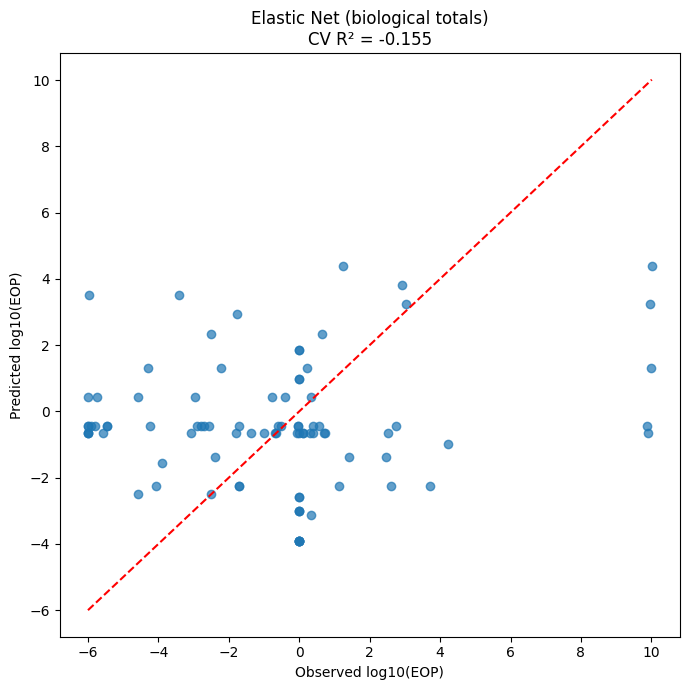

In [46]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score

# ==========================================================
# 1. ---------------- BACTERIAL TOTAL TRAITS ----------------
# ==========================================================

# defense systems (already aggregated per bacteria-subtype)
bact_defense = def_df_melted.groupby("bacteria")["count"].sum().reset_index()
bact_defense.rename(columns={"count": "total_defense_traits"}, inplace=True)

# AMR class counts
bact_amr = amr_class_counts_melt.groupby("bacteria")["count"].sum().reset_index()
bact_amr.rename(columns={"count": "total_amr_traits"}, inplace=True)

# AMR phenotype counts (optional but useful)
bact_amr_pheno = amr_phenoT_melt.groupby("bacteria")["count"].sum().reset_index()
bact_amr_pheno.rename(columns={"count": "total_amr_phenotype_traits"}, inplace=True)

# merge bacterial summaries
bacterial_summary = bact_defense.merge(bact_amr, on="bacteria", how="outer")
bacterial_summary = bacterial_summary.merge(bact_amr_pheno, on="bacteria", how="outer")

bacterial_summary = bacterial_summary.fillna(0)

# ==========================================================
# 2. ---------------- PHAGE TOTAL TRAITS ----------------
# ==========================================================

# total genes per phage cluster (sum across clusters)
phage_total_clusters = phage_cluster_counts.groupby("queryID")["gene_count"].sum().reset_index()
phage_total_clusters.rename(columns={"gene_count": "total_phage_genes"}, inplace=True)

# OPTIONAL: keep cluster diversity too (often important biologically)
phage_cluster_diversity = phage_cluster_counts.groupby("queryID")["cluster"].nunique().reset_index()
phage_cluster_diversity.rename(columns={"cluster": "cluster_diversity"}, inplace=True)

phage_summary = phage_total_clusters.merge(
    phage_cluster_diversity,
    on="queryID",
    how="outer"
).fillna(0)

# ==========================================================
# 3. ---------------- INTERACTION TABLE ----------------
# ==========================================================

interaction_df = (
    df[['phage_id', 'bacteria', 'log_EOP']]
    .drop_duplicates()
    .copy()
)

# merge bacterial + phage summaries
interaction_df = interaction_df.merge(
    bacterial_summary,
    on="bacteria",
    how="left"
)

interaction_df = interaction_df.merge(
    phage_summary,
    left_on="phage_id",
    right_on="queryID",
    how="left"
)

interaction_df = interaction_df.drop(columns=["queryID"])

interaction_df = interaction_df.fillna(0)

# ==========================================================
# 4. ---------------- FEATURES + TARGET ----------------
# ==========================================================

feature_cols = [
    "total_defense_traits",
    "total_amr_traits",
    "total_amr_phenotype_traits",
    "total_phage_genes",
    "cluster_diversity"
]

X = interaction_df[feature_cols]
y = interaction_df["log_EOP"]

# remove constant columns
X = X.loc[:, X.nunique() > 1]

# ==========================================================
# 5. ---------------- STANDARDIZE ----------------
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 6. ---------------- LASSO ----------------
# ==========================================================

lasso = LassoCV(cv=5, max_iter=20000, random_state=42)
lasso.fit(X_scaled, y)

lasso_pred = cross_val_predict(lasso, X_scaled, y, cv=5)

lasso_r2 = r2_score(y, lasso_pred)

print("\n================ LASSO ================")
print("CV R²:", round(lasso_r2, 3))
print("alpha:", lasso.alpha_)

lasso_coef = pd.DataFrame({
    "feature": X.columns,
    "coef": lasso.coef_
})

print("\nLASSO coefficients:")
print(lasso_coef)

# ==========================================================
# 7. ---------------- ELASTIC NET ----------------
# ==========================================================

enet = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    max_iter=20000,
    random_state=42
)

enet.fit(X_scaled, y)

enet_pred = cross_val_predict(enet, X_scaled, y, cv=5)

enet_r2 = r2_score(y, enet_pred)

print("\n============== ELASTIC NET ==============")
print("CV R²:", round(enet_r2, 3))
print("alpha:", enet.alpha_)
print("l1_ratio:", enet.l1_ratio_)

enet_coef = pd.DataFrame({
    "feature": X.columns,
    "coef": enet.coef_
})

print("\nElastic Net coefficients:")
print(enet_coef)

# ==========================================================
# 8. ---------------- PLOT ----------------
# ==========================================================

plt.figure(figsize=(7,7))

plt.scatter(y, enet_pred, alpha=0.7)

lims = [min(y.min(), enet_pred.min()), max(y.max(), enet_pred.max())]
plt.plot(lims, lims, "r--")

plt.xlabel("Observed log10(EOP)")
plt.ylabel("Predicted log10(EOP)")
plt.title(f"Elastic Net (biological totals)\nCV R² = {enet_r2:.3f}")

plt.tight_layout()
plt.show()


================ SINGLE TRAIT REGRESSIONS ================

total_defense_traits
  R² = 0.004, p = 5.430e-01, slope = 0.069

total_amr_traits
  R² = 0.000, p = 9.574e-01, slope = 0.019

total_amr_phenotype_traits
  R² = 0.003, p = 5.818e-01, slope = 0.055

total_phage_genes
  R² = 0.037, p = 6.935e-02, slope = 0.742

cluster_diversity
  R² = 0.001, p = 7.250e-01, slope = -0.201

================ BACTERIAL MODEL ================
R²: 0.018

================ BACTERIAL MODEL ================
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                    0.5292
Date:                Tue, 16 Jun 2026   Prob (F-statistic):              0.663
Time:                        07:31:03   Log-Likelihood:                -243.11
No. Observations:               

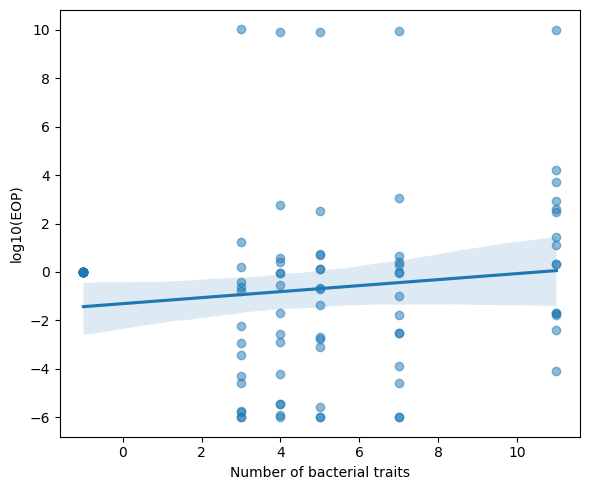

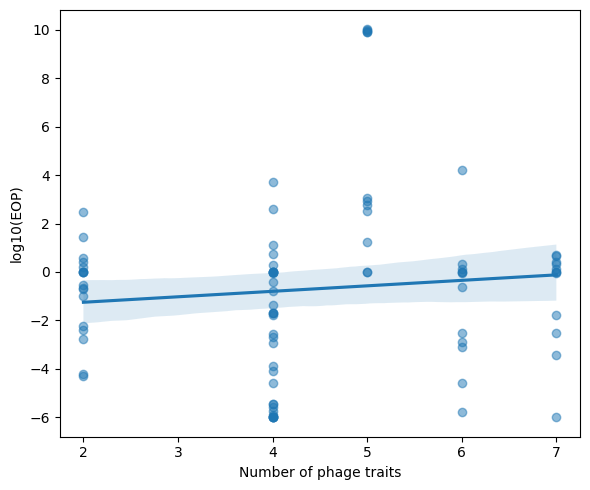

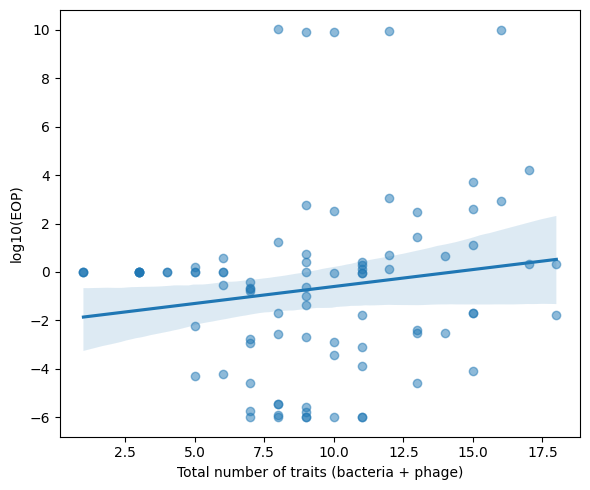

In [47]:

from sklearn.linear_model import LinearRegression
from scipy.stats import linregress

# ==========================================================
# 9. ---------------- SIMPLE LINEAR REGRESSION (SINGLE FEATURES)
# ==========================================================

print("\n================ SINGLE TRAIT REGRESSIONS ================")

for col in X.columns:
    x = interaction_df[[col]].values
    y_vals = interaction_df["log_EOP"].values

    # clean
    mask = ~np.isnan(x.flatten()) & ~np.isnan(y_vals)
    x_clean = x[mask]
    y_clean = y_vals[mask]

    if len(np.unique(x_clean)) > 1:
        slope, intercept, r, p, se = linregress(x_clean.flatten(), y_clean)

        print(f"\n{col}")
        print(f"  R² = {r**2:.3f}, p = {p:.3e}, slope = {slope:.3f}")

# ==========================================================
# 10. ---------------- BACTERIAL TRAITS ONLY
# ==========================================================

bact_cols = [
    "total_defense_traits",
    "total_amr_traits",
    "total_amr_phenotype_traits"
]

X_bact = interaction_df[bact_cols].values
y_vals = interaction_df["log_EOP"].values

mask = ~np.isnan(X_bact).any(axis=1) & ~np.isnan(y_vals)

model_bact = LinearRegression()
model_bact.fit(X_bact[mask], y_vals[mask])

pred_bact = model_bact.predict(X_bact[mask])
r2_bact = r2_score(y_vals[mask], pred_bact)

print("\n================ BACTERIAL MODEL ================")
print("R²:", round(r2_bact, 3))

import statsmodels.api as sm

# ==========================================================
# 10. BACTERIAL MODEL (with p-values)
# ==========================================================

X_bact_df = pd.DataFrame(X_bact, columns=bact_cols)[mask]
y_bact = y_vals[mask]

X_bact_sm = sm.add_constant(X_bact_df)

model_bact = sm.OLS(y_bact, X_bact_sm).fit()

print("\n================ BACTERIAL MODEL ================")
print(model_bact.summary())


# ==========================================================
# 11. ---------------- PHAGE TRAITS ONLY
# ==========================================================

phage_cols = [
    "total_phage_genes",
    "cluster_diversity"
]

X_phage = interaction_df[phage_cols].values

mask = ~np.isnan(X_phage).any(axis=1) & ~np.isnan(y_vals)

model_phage = LinearRegression()
model_phage.fit(X_phage[mask], y_vals[mask])

pred_phage = model_phage.predict(X_phage[mask])
r2_phage = r2_score(y_vals[mask], pred_phage)

print("\n================ PHAGE MODEL ================")
print("R²:", round(r2_phage, 3))

# ==========================================================
# 11. PHAGE MODEL (with p-values)
# ==========================================================

X_phage_df = pd.DataFrame(X_phage, columns=phage_cols)[mask]
y_phage = y_vals[mask]

X_phage_sm = sm.add_constant(X_phage_df)

model_phage = sm.OLS(y_phage, X_phage_sm).fit()

print("\n================ PHAGE MODEL ================")
print(model_phage.summary())

# ==========================================================
# 12. ---------------- COMBINED MODEL
# ==========================================================

X_all = interaction_df[X.columns].values

mask = ~np.isnan(X_all).any(axis=1) & ~np.isnan(y_vals)

model_all = LinearRegression()
model_all.fit(X_all[mask], y_vals[mask])

pred_all = model_all.predict(X_all[mask])
r2_all = r2_score(y_vals[mask], pred_all)

print("\n================ COMBINED LINEAR MODEL ================")
print("R²:", round(r2_all, 3))


# ==========================================================
# 12. COMBINED MODEL (with p-values)
# ==========================================================

X_all_df = pd.DataFrame(X_all, columns=X.columns)[mask]
y_all = y_vals[mask]

X_all_sm = sm.add_constant(X_all_df)

model_all = sm.OLS(y_all, X_all_sm).fit()

print("\n================ COMBINED MODEL ================")
print(model_all.summary())

# ==========================================================
# 13. ---------------- VISUAL CHECK (COMBINED)
# ==========================================================


import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINE TRAIT BURDENS
# ==========================================================

interaction_df["bacterial_trait_burden"] = (
    interaction_df["total_defense_traits"] +
    interaction_df["total_amr_traits"] +
    interaction_df["total_amr_phenotype_traits"]
)

interaction_df["phage_trait_burden"] = (
    interaction_df["total_phage_genes"] +
    interaction_df["cluster_diversity"]
)

interaction_df["combined_trait_burden"] = (
    interaction_df["bacterial_trait_burden"] +
    interaction_df["phage_trait_burden"]
)

# ==========================================================
# 2. PLOT: BACTERIAL TRAITS vs EOP
# ==========================================================

plt.figure(figsize=(6,5))
sns.regplot(
    data=interaction_df,
    x="bacterial_trait_burden",
    y="log_EOP",
    scatter_kws={"alpha": 0.5}
)

plt.xlabel("Number of bacterial traits")
plt.ylabel("log10(EOP)")
plt.tight_layout()
plt.show()

# ==========================================================
# 3. PLOT: PHAGE TRAITS vs EOP
# ==========================================================

plt.figure(figsize=(6,5))
sns.regplot(
    data=interaction_df,
    x="phage_trait_burden",
    y="log_EOP",
    scatter_kws={"alpha": 0.5}
)

plt.xlabel("Number of phage traits")
plt.ylabel("log10(EOP)")
plt.tight_layout()
plt.show()

# ==========================================================
# 4. PLOT: COMBINED TRAITS vs EOP
# ==========================================================

plt.figure(figsize=(6,5))
sns.regplot(
    data=interaction_df,
    x="combined_trait_burden",
    y="log_EOP",
    scatter_kws={"alpha": 0.5}
)

plt.xlabel("Total number of traits (bacteria + phage)")
plt.ylabel("log10(EOP)")
plt.tight_layout()
plt.show()


# Linear mixed effect model

## Condition 1
Testing to check if bacterial host species, i.e. xylosoxidans and inoslitus - have effects on logEOP - and which variables explain this

In [48]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import pandas as pd
import numpy as np

# Make sure categorical variables are correctly typed
categorical_cols = [
    "subtype",            # Defence system
    "AMR_class_x",        # AMR gene class
    "AMR_phenotype",      # AMR phenotype
    "phage_tail_clusters", # Phage genomic cluster
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# Make sure log_EOP exists
df["log_EOP"] = np.log10(df["EOP_value"])

# Fit the full LMM
model = mixedlm(
    "log_EOP ~ subtype + AMR_class_x + AMR_phenotype + phage_tail_clusters",
    data=df,
    groups=df["host_species"]  # random intercept for each bacterial species
)

result = model.fit()
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           log_EOP     
No. Observations:             40176             Method:                       REML        
No. Groups:                   2                 Scale:                        12.8801     
Min. group size:              11160             Log-Likelihood:               -108392.2057
Max. group size:              29016             Converged:                    Yes         
Mean group size:              20088.0                                                     
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.707    1.343   0.527 0.598 -1.926  3.340
subtype[T.CBASS_II]       

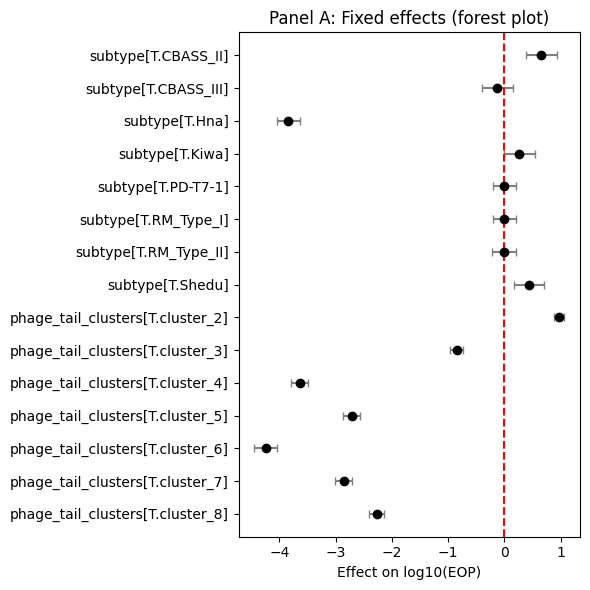

In [49]:
# Extract coefficients and 95% CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Optional: select only effects of interest
effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]

# Plot
plt.figure(figsize=(6, len(coefs_sel)*0.4))
plt.errorbar(coefs_sel, range(len(coefs_sel)),
             xerr=[coefs_sel - ci_lower_sel, ci_upper_sel - coefs_sel],
             fmt='o', color='black', ecolor='gray', capsize=3)
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.axvline(0, color='red', linestyle='--')
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Panel A: Fixed effects (forest plot)")
plt.tight_layout()
plt.show()


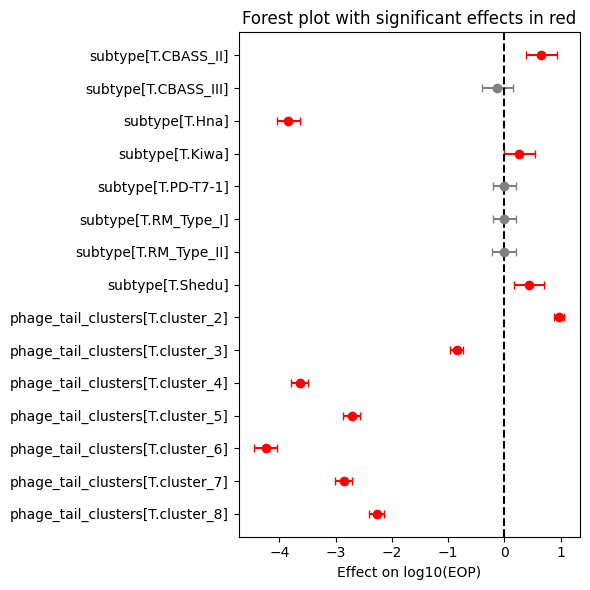

In [50]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

Data loaded successfully!
Shape: (40176, 15)

Columns: ['EOP_value', 'phage_id', 'bacteria', 'host_species', 'log_EOP', 'subtype', 'defense_genes_counts', 'AMR_class_x', 'count_x', 'AMR_phenotype', 'phenotype', 'queryID', 'phage_taxa', 'phage_tail_clusters', 'phage_tail_cluster_gene_count']

First few rows:
     phage_id             bacteria  log_EOP phage_tail_clusters subtype
0  coliflower  A xylosoxidans jini  1.25042           cluster_1     Hna
1  coliflower  A xylosoxidans jini  1.25042           cluster_2     Hna
2  coliflower  A xylosoxidans jini  1.25042           cluster_1     Hna
3  coliflower  A xylosoxidans jini  1.25042           cluster_2     Hna
4  coliflower  A xylosoxidans jini  1.25042           cluster_1     Hna

CREATING OPTION 1: HEATMAP + RIDGE PLOT (RECOMMENDED)

Figure saved to: eop_heatmap_ridge.png


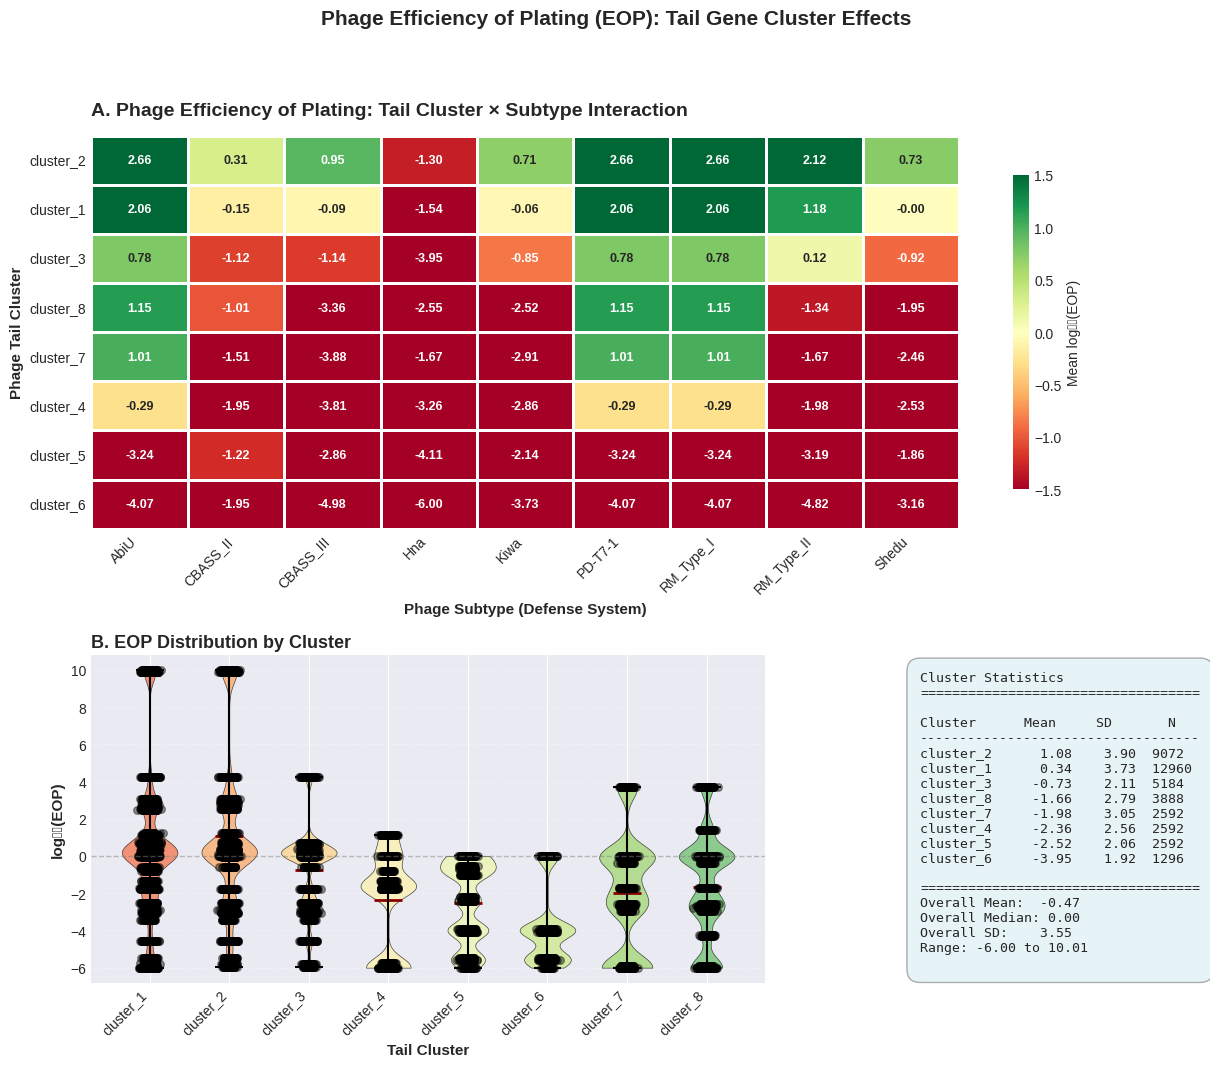


CREATING OPTION 2: FOREST PLOT

Figure saved to: eop_forest.png


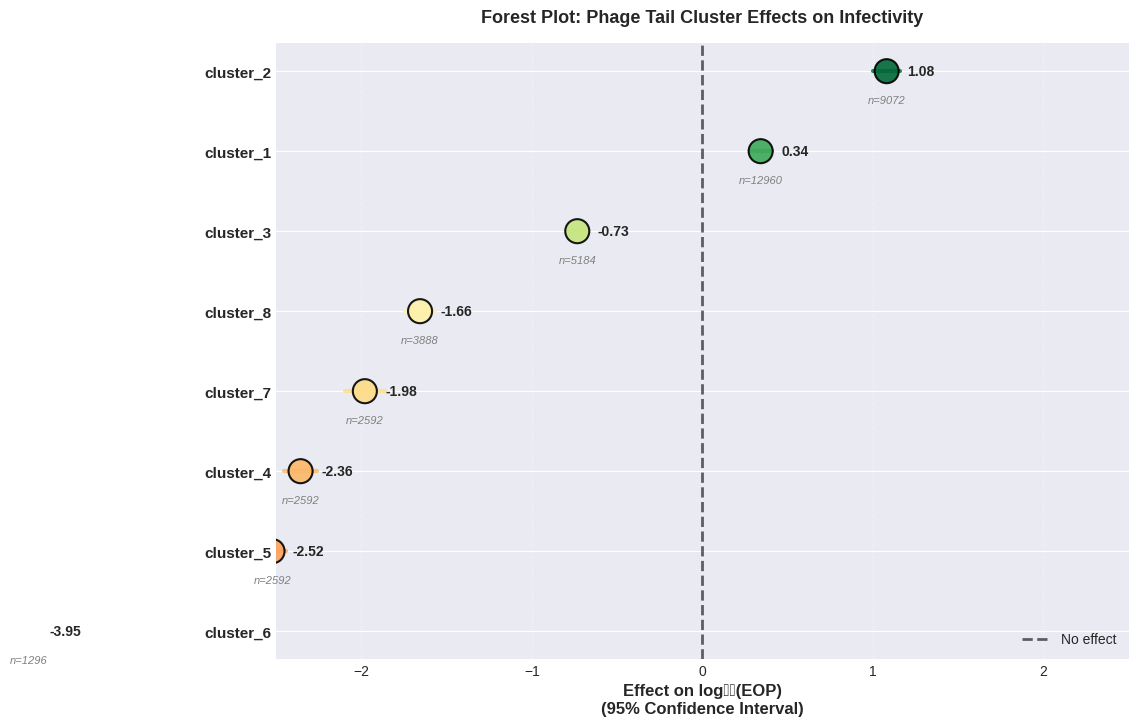


CREATING OPTION 3: 4-PANEL DASHBOARD

Figure saved to: eop_dashboard.png


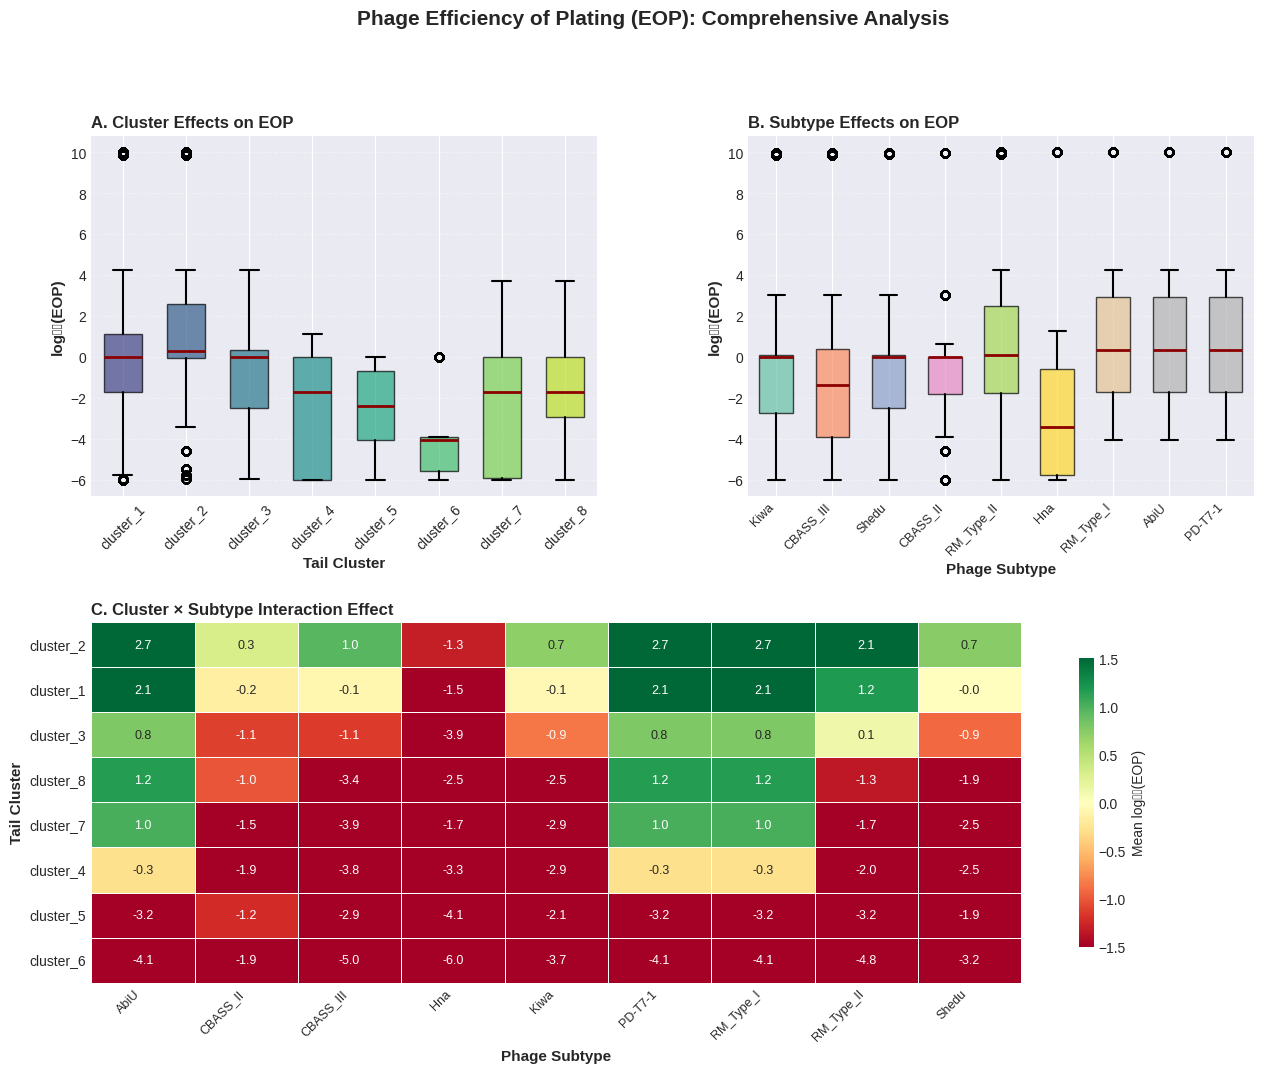


✓ All plots created successfully!

Files saved:
  - eop_heatmap_ridge.png (RECOMMENDED)
  - eop_forest.png
  - eop_dashboard.png

Use Option 1 (Heatmap + Ridge) for your publication figure.


In [51]:
"""
=============================================================================
COMPLETE EOP VISUALIZATION CODE
=============================================================================
Copy and paste this entire script into a Jupyter cell or Python script.
Change the data path in line ~40 to match your file location.
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# =============================================================================
# LOAD DATA
# =============================================================================
# UPDATE THIS PATH TO YOUR DATA FILE
df = pd.read_csv("merged_all_data.csv")

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df[['phage_id', 'bacteria', 'log_EOP', 'phage_tail_clusters', 'subtype']].head())

# =============================================================================
# OPTION 1: HEATMAP + RIDGE PLOT (RECOMMENDED)
# =============================================================================

def plot_eop_heatmap_ridge(df, figsize=(14, 11), save_path=None):
    """
    Comprehensive EOP visualization with heatmap and distribution ridge plot.

    Parameters:
    -----------
    df : pandas.DataFrame
        Data with columns: log_EOP, phage_tail_clusters, subtype
    figsize : tuple
        Figure size (width, height)
    save_path : str or None
        Path to save figure. If None, doesn't save.

    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    axes : tuple
        Tuple of (ax1, ax2, ax3) - heatmap, ridge plot, and stats
    """

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], width_ratios=[2.5, 1],
                          hspace=0.35, wspace=0.3)

    # =========================================================================
    # PANEL A: HEATMAP (Cluster × Subtype Interaction)
    # =========================================================================
    ax1 = fig.add_subplot(gs[0, :])

    # Create pivot table: clusters (rows) × subtypes (columns)
    pivot_data = df.pivot_table(
        values='log_EOP',
        index='phage_tail_clusters',
        columns='subtype',
        aggfunc='mean'
    )

    # Sort clusters by mean effect size
    cluster_means = df.groupby('phage_tail_clusters')['log_EOP'].mean().sort_values(ascending=False)
    pivot_data = pivot_data.loc[cluster_means.index]

    # Create heatmap
    sns.heatmap(pivot_data,
                cmap='RdYlGn',
                center=0,
                ax=ax1,
                cbar_kws={'label': 'Mean log₁₀(EOP)', 'shrink': 0.8},
                vmin=-1.5,
                vmax=1.5,
                linewidths=0.8,
                linecolor='white',
                annot=True,
                fmt='.2f',
                annot_kws={'fontsize': 9, 'fontweight': 'bold'},
                cbar=True)

    ax1.set_title('A. Phage Efficiency of Plating: Tail Cluster × Subtype Interaction',
                  fontsize=14, fontweight='bold', loc='left', pad=15)
    ax1.set_xlabel('Phage Subtype (Defense System)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Phage Tail Cluster', fontsize=11, fontweight='bold')

    # Rotate x-axis labels
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=10)

    # =========================================================================
    # PANEL B: VIOLIN/RIDGE PLOT (Distribution by Cluster)
    # =========================================================================
    ax2 = fig.add_subplot(gs[1, 0])

    cluster_order = sorted(df['phage_tail_clusters'].unique())
    data_for_violin = [df[df['phage_tail_clusters'] == c]['log_EOP'].values
                       for c in cluster_order]

    # Create violin plot
    parts = ax2.violinplot(
        data_for_violin,
        positions=np.arange(len(cluster_order)),
        widths=0.7,
        showmeans=True,
        showmedians=False,
        showextrema=True
    )

    # Color the violins with a gradient
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cluster_order)))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)

    # Style the other violin elements
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if partname in parts:
            vp = parts[partname]
            vp.set_edgecolor('black')
            vp.set_linewidth(1.5)

    # Style mean markers
    parts['cmeans'].set_edgecolor('darkred')
    parts['cmeans'].set_linewidth(2)

    # Add individual points with jitter
    for i, cluster in enumerate(cluster_order):
        y_data = df[df['phage_tail_clusters'] == cluster]['log_EOP'].values
        x_data = np.random.normal(i, 0.04, size=len(y_data))
        ax2.scatter(x_data, y_data, alpha=0.4, s=30, color='black', zorder=2)

    ax2.set_xticks(np.arange(len(cluster_order)))
    ax2.set_xticklabels(cluster_order, rotation=45, ha='right', fontsize=10)
    ax2.set_xlabel('Tail Cluster', fontsize=11, fontweight='bold')
    ax2.set_ylabel('log₁₀(EOP)', fontsize=11, fontweight='bold')
    ax2.set_title('B. EOP Distribution by Cluster', fontsize=13, fontweight='bold', loc='left')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    # =========================================================================
    # PANEL C: SUMMARY STATISTICS
    # =========================================================================
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    # Calculate cluster statistics
    cluster_stats = df.groupby('phage_tail_clusters')['log_EOP'].agg(['mean', 'std', 'count'])
    cluster_stats = cluster_stats.sort_values('mean', ascending=False)

    # Build statistics text
    stats_text = "Cluster Statistics\n" + "="*35 + "\n\n"
    stats_text += f"{'Cluster':<12} {'Mean':<8} {'SD':<8} {'N':<4}\n"
    stats_text += "-"*35 + "\n"

    for cluster, row in cluster_stats.iterrows():
        stats_text += f"{str(cluster):<12} {row['mean']:>6.2f}  {row['std']:>6.2f}  {int(row['count']):>3}\n"

    # Add overall statistics
    stats_text += "\n" + "="*35 + "\n"
    stats_text += f"Overall Mean:  {df['log_EOP'].mean():.2f}\n"
    stats_text += f"Overall Median: {df['log_EOP'].median():.2f}\n"
    stats_text += f"Overall SD:    {df['log_EOP'].std():.2f}\n"
    stats_text += f"Range: {df['log_EOP'].min():.2f} to {df['log_EOP'].max():.2f}\n"

    ax3.text(0.05, 0.95, stats_text,
             transform=ax3.transAxes,
             fontsize=9.5,
             verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3, pad=1))

    # =========================================================================
    # OVERALL TITLE
    # =========================================================================
    fig.suptitle('Phage Efficiency of Plating (EOP): Tail Gene Cluster Effects',
                 fontsize=15, fontweight='bold', y=0.995)

    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\nFigure saved to: {save_path}")

    return fig, (ax1, ax2, ax3)


# =============================================================================
# OPTION 2: FOREST PLOT (EFFECT SIZES)
# =============================================================================

def plot_eop_forest(df, figsize=(11, 8), save_path=None):
    """
    Forest plot showing cluster effects on log_EOP with 95% confidence intervals.

    Parameters:
    -----------
    df : pandas.DataFrame
        Data with columns: log_EOP, phage_tail_clusters
    figsize : tuple
        Figure size
    save_path : str or None
        Path to save figure

    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    ax : matplotlib.axes.Axes
        The axes object
    """

    fig, ax = plt.subplots(figsize=figsize)

    # Calculate cluster effects and confidence intervals
    cluster_stats = df.groupby('phage_tail_clusters')['log_EOP'].agg(['mean', 'std', 'count'])

    # Calculate 95% CI using t-distribution
    cluster_stats['se'] = cluster_stats['std'] / np.sqrt(cluster_stats['count'])
    cluster_stats['ci_lower'] = cluster_stats['mean'] - 1.96 * cluster_stats['se']
    cluster_stats['ci_upper'] = cluster_stats['mean'] + 1.96 * cluster_stats['se']

    # Sort by effect size
    cluster_stats = cluster_stats.sort_values('mean', ascending=True)

    # Create color gradient based on effect size
    norm = plt.Normalize(vmin=cluster_stats['mean'].min(), vmax=cluster_stats['mean'].max())
    colors = plt.cm.RdYlGn(norm(cluster_stats['mean']))

    # Plot
    y_pos = np.arange(len(cluster_stats))

    # Plot confidence intervals as lines
    for i, (idx, row) in enumerate(cluster_stats.iterrows()):
        ax.plot([row['ci_lower'], row['ci_upper']], [i, i],
                color=colors[i], linewidth=3, alpha=0.8, zorder=1)

    # Plot point estimates as circles
    ax.scatter(cluster_stats['mean'], y_pos, s=300, color=colors, zorder=3,
               edgecolors='black', linewidth=1.5, alpha=0.9)

    # Add vertical null line (no effect)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.6, label='No effect')

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cluster_stats.index, fontsize=11, fontweight='bold')
    ax.set_xlabel('Effect on log₁₀(EOP)\n(95% Confidence Interval)',
                  fontsize=12, fontweight='bold')
    ax.set_title('Forest Plot: Phage Tail Cluster Effects on Infectivity',
                 fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(-2.5, 2.5)

    # Add effect magnitude annotations
    for i, (idx, row) in enumerate(cluster_stats.iterrows()):
        ax.text(row['mean'] + 0.12, i, f"{row['mean']:.2f}",
                va='center', fontsize=10, fontweight='bold')
        ax.text(row['mean'], i - 0.3, f"n={int(row['count'])}",
                va='top', ha='center', fontsize=8, color='gray', style='italic')

    # Add legend
    ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\nFigure saved to: {save_path}")

    return fig, ax


# =============================================================================
# OPTION 3: 4-PANEL DASHBOARD
# =============================================================================

def plot_eop_dashboard(df, figsize=(15, 11), save_path=None):
    """
    Comprehensive 4-panel dashboard showing multiple aspects of EOP variation.

    Parameters:
    -----------
    df : pandas.DataFrame
        Complete data frame
    figsize : tuple
        Figure size
    save_path : str or None
        Path to save figure

    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    axes : tuple
        Tuple of (ax_a, ax_b, ax_c) for the three subplots
    """

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

    # =========================================================================
    # PANEL A: CLUSTER EFFECTS (Box/Violin plot)
    # =========================================================================
    ax_a = fig.add_subplot(gs[0, 0])

    cluster_order = sorted(df['phage_tail_clusters'].unique())
    data_a = [df[df['phage_tail_clusters'] == c]['log_EOP'].values for c in cluster_order]

    bp_a = ax_a.boxplot(data_a, labels=cluster_order, patch_artist=True, widths=0.6)

    colors_a = plt.cm.viridis(np.linspace(0.2, 0.9, len(cluster_order)))
    for patch, color in zip(bp_a['boxes'], colors_a):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')

    for whisker in bp_a['whiskers']:
        whisker.set(linewidth=1.5, color='black')
    for cap in bp_a['caps']:
        cap.set(linewidth=1.5, color='black')
    for median in bp_a['medians']:
        median.set(linewidth=2, color='darkred')

    ax_a.set_xlabel('Tail Cluster', fontsize=11, fontweight='bold')
    ax_a.set_ylabel('log₁₀(EOP)', fontsize=11, fontweight='bold')
    ax_a.set_title('A. Cluster Effects on EOP', fontsize=12, fontweight='bold', loc='left')
    ax_a.grid(axis='y', alpha=0.3, linestyle='--')
    ax_a.tick_params(axis='x', rotation=45)

    # =========================================================================
    # PANEL B: SUBTYPE EFFECTS (Box/Violin plot)
    # =========================================================================
    ax_b = fig.add_subplot(gs[0, 1])

    subtype_order = df['subtype'].value_counts().index
    data_b = [df[df['subtype'] == st]['log_EOP'].values for st in subtype_order]

    bp_b = ax_b.boxplot(data_b, labels=subtype_order, patch_artist=True, widths=0.6)

    colors_b = plt.cm.Set2(np.linspace(0, 1, len(subtype_order)))
    for patch, color in zip(bp_b['boxes'], colors_b):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')

    for whisker in bp_b['whiskers']:
        whisker.set(linewidth=1.5, color='black')
    for cap in bp_b['caps']:
        cap.set(linewidth=1.5, color='black')
    for median in bp_b['medians']:
        median.set(linewidth=2, color='darkred')

    ax_b.set_xlabel('Phage Subtype', fontsize=11, fontweight='bold')
    ax_b.set_ylabel('log₁₀(EOP)', fontsize=11, fontweight='bold')
    ax_b.set_title('B. Subtype Effects on EOP', fontsize=12, fontweight='bold', loc='left')
    ax_b.grid(axis='y', alpha=0.3, linestyle='--')
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

    # =========================================================================
    # PANEL C: HEATMAP (Cluster × Subtype Interaction)
    # =========================================================================
    ax_c = fig.add_subplot(gs[1, :])

    pivot_data = df.pivot_table(
        values='log_EOP',
        index='phage_tail_clusters',
        columns='subtype',
        aggfunc='mean'
    )

    # Sort by cluster mean
    cluster_means = df.groupby('phage_tail_clusters')['log_EOP'].mean().sort_values(ascending=False)
    pivot_data = pivot_data.loc[cluster_means.index]

    sns.heatmap(pivot_data,
                cmap='RdYlGn',
                center=0,
                ax=ax_c,
                cbar_kws={'label': 'Mean log₁₀(EOP)', 'shrink': 0.8},
                vmin=-1.5,
                vmax=1.5,
                annot=True,
                fmt='.1f',
                annot_kws={'fontsize': 9},
                linewidths=0.5,
                linecolor='white')

    ax_c.set_xlabel('Phage Subtype', fontsize=11, fontweight='bold')
    ax_c.set_ylabel('Tail Cluster', fontsize=11, fontweight='bold')
    ax_c.set_title('C. Cluster × Subtype Interaction Effect', fontsize=12, fontweight='bold', loc='left')
    plt.setp(ax_c.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

    # =========================================================================
    # OVERALL TITLE
    # =========================================================================
    fig.suptitle('Phage Efficiency of Plating (EOP): Comprehensive Analysis',
                 fontsize=15, fontweight='bold', y=0.995)

    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\nFigure saved to: {save_path}")

    return fig, (ax_a, ax_b, ax_c)


# =============================================================================
# CREATE ALL THREE PLOTS
# =============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("CREATING OPTION 1: HEATMAP + RIDGE PLOT (RECOMMENDED)")
    print("="*80)
    fig1, axes1 = plot_eop_heatmap_ridge(df, figsize=(14, 11),
                                         save_path='eop_heatmap_ridge.png')
    plt.show()

    print("\n" + "="*80)
    print("CREATING OPTION 2: FOREST PLOT")
    print("="*80)
    fig2, ax2 = plot_eop_forest(df, figsize=(11, 8),
                                save_path='eop_forest.png')
    plt.show()

    print("\n" + "="*80)
    print("CREATING OPTION 3: 4-PANEL DASHBOARD")
    print("="*80)
    fig3, axes3 = plot_eop_dashboard(df, figsize=(15, 11),
                                     save_path='eop_dashboard.png')
    plt.show()

    print("\n" + "="*80)
    print("✓ All plots created successfully!")
    print("="*80)
    print("\nFiles saved:")
    print("  - eop_heatmap_ridge.png (RECOMMENDED)")
    print("  - eop_forest.png")
    print("  - eop_dashboard.png")
    print("\nUse Option 1 (Heatmap + Ridge) for your publication figure.")

# Condition 2

Testing if the phage taxa have any effect on EOP, and what variables explain that

In [52]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import pandas as pd
import numpy as np

# Make sure categorical variables are correctly typed
categorical_cols = [
    "subtype",            # Defence system
    "AMR_class_x",        # AMR gene class
    "AMR_phenotype",      # AMR phenotype
    "phage_tail_clusters", # Phage genomic cluster
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# Make sure log_EOP exists
df["log_EOP"] = np.log10(df["EOP_value"])

# Fit the full LMM
model = mixedlm(
    "log_EOP ~ subtype + AMR_class_x + AMR_phenotype + phage_tail_clusters",
    data=df,
    groups=df["phage_taxa"]  # random intercept for each phage taxa
)

result = model.fit()
print(result.summary())


                           Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_EOP     
No. Observations:            40176              Method:                        REML        
No. Groups:                  2                  Scale:                         13.0731     
Min. group size:             6480               Log-Likelihood:                -108687.4924
Max. group size:             33696              Converged:                     Yes         
Mean group size:             20088.0                                                       
-------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                       2.024    3.617   0.559 0.576  -5.066  9.113
subtype[T.CBASS

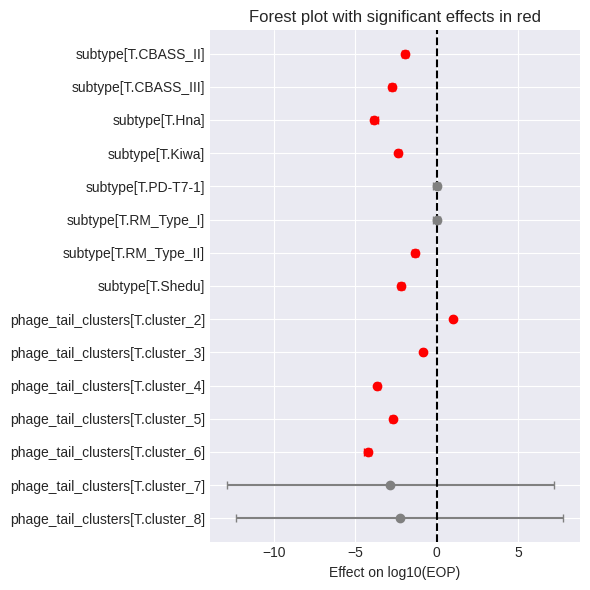

In [53]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

# Condition 3

Tested if both phage and bacterial taxa have any effect

In [54]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# Ensure categorical types
df["phage_taxa"] = df["phage_taxa"].astype("category")
df["host_species"] = df["host_species"].astype("category")

# Fixed effects example (adjust as needed)
fixed_effects = "subtype + AMR_class_x + AMR_phenotype + phage_tail_clusters"

# Variance components for multiple random effects
vc = {
    "phage_taxa": "0 + C(phage_taxa)",
    "host_species": "0 + C(host_species)"
}

# Fit the mixed model
model = mixedlm(
    f"log_EOP ~ {fixed_effects}",
    data=df,
    groups=df["bacteria"],  # still need a main grouping for random intercept
    vc_formula=vc
)

result = model.fit()
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           log_EOP     
No. Observations:             40176             Method:                       REML        
No. Groups:                   6                 Scale:                        12.0389     
Min. group size:              2232              Log-Likelihood:               -107062.0154
Max. group size:              8928              Converged:                    Yes         
Mean group size:              6696.0                                                      
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                      -0.056    0.976  -0.057 0.954 -1.970  1.858
subtype[T.CBASS_II]       

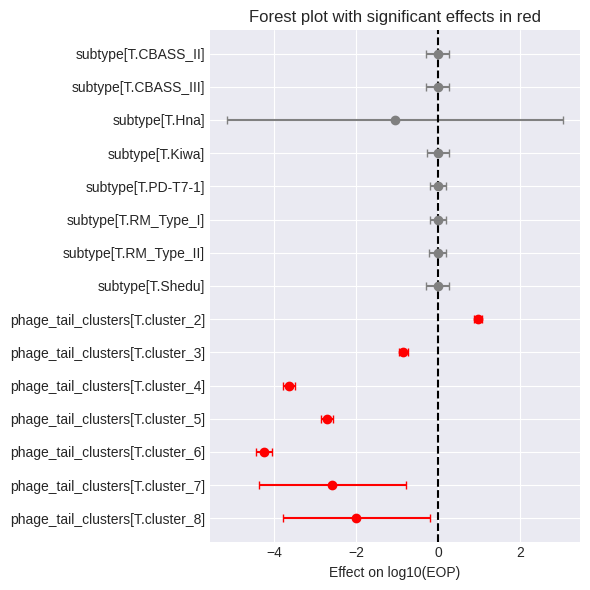

In [55]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

# Condition 4

Since defense systems and phage tail clusters consistently come up as significant in the model. I am testing to see if their interaction matters (as a fixed effect together)

In [56]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# Ensure categorical types
df["phage_taxa"] = df["phage_taxa"].astype("category")
df["host_species"] = df["host_species"].astype("category")

# Fixed effects example (adjust as needed)
fixed_effects = "subtype * phage_tail_clusters"

# Variance components for multiple random effects
vc = {
    "phage_taxa": "0 + C(phage_taxa)",
    "host_species": "0 + C(host_species)"
}

# Fit the mixed model
model = mixedlm(
    f"log_EOP ~ {fixed_effects}",
    data=df,
    groups=df["bacteria"],  # still need a main grouping for random intercept
    vc_formula=vc
)

result = model.fit()
print(result.summary())


                              Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              log_EOP     
No. Observations:               40176                Method:                          REML        
No. Groups:                     6                    Scale:                           11.7324     
Min. group size:                2232                 Log-Likelihood:                  -106518.8865
Max. group size:                8928                 Converged:                       Yes         
Mean group size:                6696.0                                                            
--------------------------------------------------------------------------------------------------
                                                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                

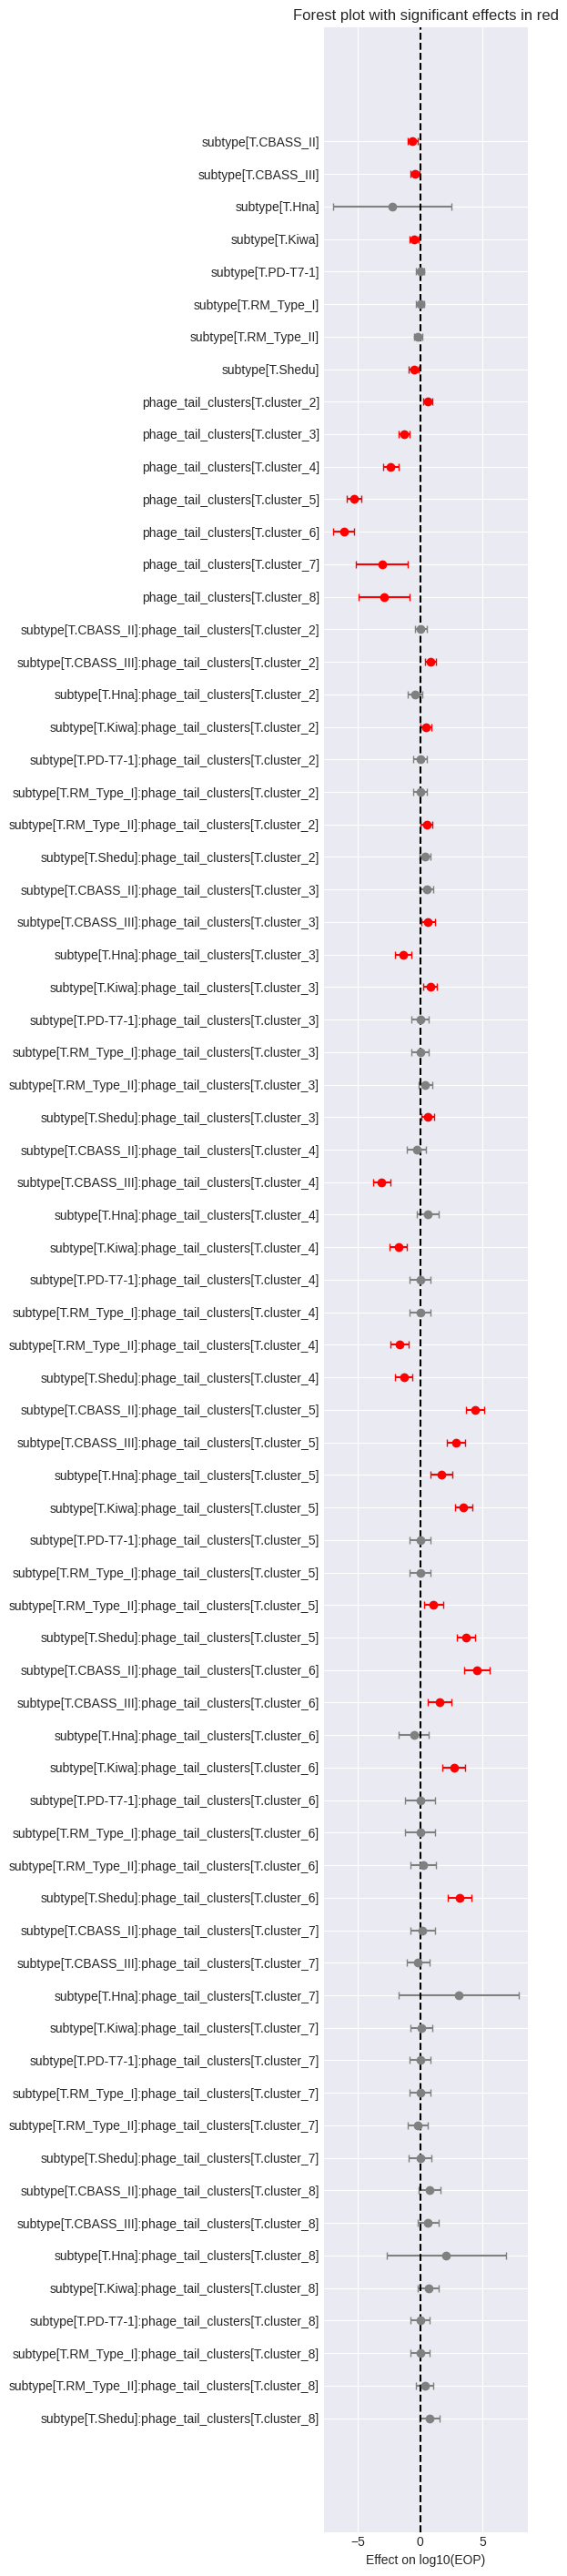

In [57]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

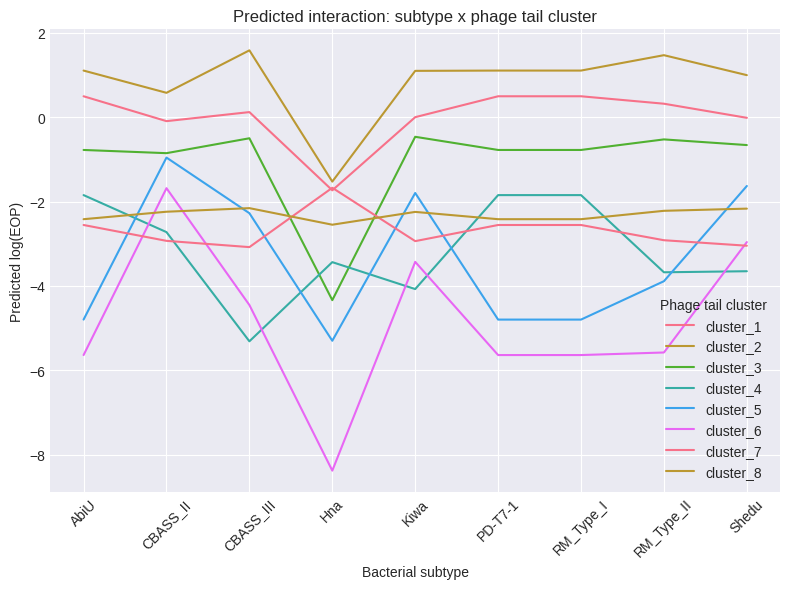

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from patsy import dmatrix

# Ensure categorical types are set for the relevant columns in the original df
df['subtype'] = df['subtype'].astype('category')
df['phage_tail_clusters'] = df['phage_tail_clusters'].astype('category')

# Choose the variables for the interaction
subtypes = df['subtype'].cat.categories
tails = df['phage_tail_clusters'].cat.categories

# Define the fixed effects formula that was used in the model for which we want to predict
# This should match the formula used in cell HUpa-UFRIe-P
fixed_effects_formula = "subtype * phage_tail_clusters"

# Create a DataFrame with all combinations of the interaction terms.
# This predict_df will initially only contain the independent variables used in the formula.
predict_df = pd.DataFrame([(s, t) for s in subtypes for t in tails], columns=['subtype', 'phage_tail_clusters'])

# Ensure categorical types in predict_df for correct dmatrix behavior
predict_df['subtype'] = predict_df['subtype'].astype('category')
predict_df['phage_tail_clusters'] = predict_df['phage_tail_clusters'].astype('category')

# Predict using the fitted model by passing the DataFrame with original column names
predict_df['fit'] = result.predict(exog=predict_df)

# Initialize columns for confidence intervals
predict_df['lower'] = np.nan
predict_df['upper'] = np.nan

# Re-calculate confidence intervals using the correct design matrix rows
params = result.params
cov = result.cov_params()

for i, row in predict_df.iterrows():
    # Create a temporary DataFrame for dmatrix for the current row
    # This DataFrame should only contain the columns present in fixed_effects_formula
    temp_df_row = pd.DataFrame([row[['subtype', 'phage_tail_clusters']].to_dict()])
    temp_df_row['subtype'] = temp_df_row['subtype'].astype('category')
    temp_df_row['phage_tail_clusters'] = temp_df_row['phage_tail_clusters'].astype('category')

    exog_row_dm = dmatrix(fixed_effects_formula, temp_df_row, return_type='dataframe')

    # Align the columns of exog_row_dm with the model's fixed effect names
    exog_row_aligned = exog_row_dm.reindex(columns=result.model.exog_names, fill_value=0)

    # Calculate standard error for the prediction
    # Check if alignment is successful and exog_row_aligned is valid
    if not exog_row_aligned.empty and exog_row_aligned.shape[1] == cov.shape[0]:
        se = np.sqrt(exog_row_aligned.values @ cov.values @ exog_row_aligned.values.T)
        predict_df.at[i, 'lower'] = row['fit'] - 1.96 * se
        predict_df.at[i, 'upper'] = row['fit'] + 1.96 * se
    else:
        print(f"Warning: Could not calculate CI for row {i} due to design matrix mismatch or invalid shape.")
        predict_df.at[i, 'lower'] = np.nan
        predict_df.at[i, 'upper'] = np.nan

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8,6))

for tail in tails:
    sub_df = predict_df[predict_df['phage_tail_clusters'] == tail]
    plt.plot(sub_df['subtype'], sub_df['fit'], label=tail)
    plt.fill_between(sub_df['subtype'], sub_df['lower'], sub_df['upper'], alpha=0.3)

plt.xlabel('Bacterial subtype')
plt.ylabel('Predicted log(EOP)')
plt.title('Predicted interaction: subtype x phage tail cluster')
plt.legend(title='Phage tail cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# =============================================================================
# FIGURE 1: FIXED EFFECTS FOREST PLOT
# =============================================================================

def plot_fixed_effects_forest(model_result, figsize=(18, 14), save_path=None):
    """
    Create forest plot of fixed effects with 95% CI.

    Parameters:
    -----------
    model_result : statsmodels MixedLM result object
        Result from model.fit()
    figsize : tuple
        Figure size
    save_path : str or None
        Path to save figure

    Returns:
    --------
    fig, ax : figure and axes objects
    """

    fixed_effects = model_result.fe_params
    se = model_result.bse

    # Combine into a single DataFrame, aligning by index
    effects_df = pd.DataFrame({
        'coef': fixed_effects,
        'se': se
    }).reset_index() # Convert index to a column
    effects_df = effects_df.rename(columns={'index': 'effect'})

    # Calculate 95% CI
    effects_df['ci_lower'] = effects_df['coef'] - 1.96 * effects_df['se']
    effects_df['ci_upper'] = effects_df['coef'] + 1.96 * effects_df['se']

    # Drop rows where 'coef' or 'se' might be NaN, which would cause issues for plotting
    effects_df.dropna(subset=['coef', 'se', 'ci_lower', 'ci_upper'], inplace=True)

    # Sort by effect size
    effects_df = effects_df.sort_values('coef')

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    y_pos = np.arange(len(effects_df))

    # Determine colors (positive/negative)
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in effects_df['coef']]

    # Plot confidence intervals
    for i, (idx, row) in enumerate(effects_df.iterrows()):
        ax.plot([row['ci_lower'], row['ci_upper']], [i, i],
                color=colors[i], linewidth=3, alpha=0.7, zorder=1)

    # Plot point estimates
    ax.scatter(effects_df['coef'], y_pos, s=200, color=colors,
              edgecolors='black', linewidth=1.5, zorder=3, alpha=0.9)

    # Add null line
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.6)

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(effects_df['effect'], fontsize=10)
    ax.set_xlabel('Fixed Effect Estimate (95% CI)', fontsize=12, fontweight='bold')
    ax.set_title('Mixed Linear Model: Fixed Effects\n(Green=positive, Red=negative)',
                fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (idx, row) in enumerate(effects_df.iterrows()):
        ax.text(row['coef'] + 0.05, i, f"{row['coef']:.3f}",
               va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, ax


# =============================================================================
# FIGURE 2: MODEL DIAGNOSTICS (4-PANEL)
# =============================================================================

def plot_model_diagnostics(model_result, y, y_pred, figsize=(14, 10), save_path=None):
    """
    Create 4-panel diagnostic plot:
    - Residuals vs Fitted
    - Q-Q plot
    - Scale-Location plot
    - Residuals histogram
    """

    residuals = y - y_pred
    standardized_resid = residuals / np.std(residuals)

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # =========================================================================
    # Panel 1: Residuals vs Fitted
    # =========================================================================
    ax = axes[0, 0]
    ax.scatter(y_pred, residuals, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Fitted Values', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
    ax.set_title('A. Residuals vs Fitted', fontsize=12, fontweight='bold', loc='left')
    ax.grid(True, alpha=0.3)

    # =========================================================================
    # Panel 2: Q-Q Plot
    # =========================================================================
    ax = axes[0, 1]
    stats.probplot(standardized_resid, dist="norm", plot=ax)
    ax.set_title('B. Normal Q-Q Plot', fontsize=12, fontweight='bold', loc='left')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markeredgecolor('steelblue')
    ax.get_lines()[0].set_markersize(8)
    ax.grid(True, alpha=0.3)

    # =========================================================================
    # Panel 3: Scale-Location (Sqrt Standardized Residuals vs Fitted)
    # =========================================================================
    ax = axes[1, 0]
    sqrt_abs_std_resid = np.sqrt(np.abs(standardized_resid))
    ax.scatter(y_pred, sqrt_abs_std_resid, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

    # Add smoothed line
    from scipy.interpolate import make_interp_spline
    sorted_idx = np.argsort(y_pred)
    x_smooth = y_pred[sorted_idx]
    y_smooth = sqrt_abs_std_resid[sorted_idx]
    spl = make_interp_spline(x_smooth, y_smooth, k=3)
    y_smooth_spline = spl(x_smooth)
    ax.plot(x_smooth, y_smooth_spline, 'r-', linewidth=2)

    ax.set_xlabel('Fitted Values', fontsize=11, fontweight='bold')
    ax.set_ylabel('√|Standardized Residuals|', fontsize=11, fontweight='bold')
    ax.set_title('C. Scale-Location', fontsize=12, fontweight='bold', loc='left')
    ax.grid(True, alpha=0.3)

    # =========================================================================
    # Panel 4: Residuals Histogram
    # =========================================================================
    ax = axes[1, 1]
    ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')

    # Add normal distribution curve
    mu, sigma = np.mean(residuals), np.std(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax.plot(x, len(residuals) * (x[1] - x[0]) * stats.norm.pdf(x, mu, sigma),
           'r-', linewidth=2, label='Normal distribution')

    ax.set_xlabel('Residuals', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('D. Residuals Distribution', fontsize=12, fontweight='bold', loc='left')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    fig.suptitle('Model Diagnostics: Mixed Linear Model',
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, axes


# =============================================================================
# FIGURE 3: VARIANCE COMPONENTS
# =============================================================================

def plot_variance_components(model_result, figsize=(10, 6), save_path=None):
    """
    Create bar plot showing variance explained by random effects.
    """

    # Extract variance components
    var_components = model_result.cov_re

    if var_components is None or len(var_components) == 0:
        print("No variance components to plot")
        return None

    # Extract diagonal (variances)
    variances = {}
    for idx in var_components.index:
        variances[str(idx)] = var_components.loc[idx, idx]

    # Residual variance
    residual_var = model_result.scale

    # Combine
    all_vars = {**variances, 'Residual': residual_var}
    all_vars = {k: v for k, v in sorted(all_vars.items(), key=lambda x: x[1], reverse=True)}

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    labels = list(all_vars.keys())
    values = list(all_vars.values())

    # Calculate proportions
    total = sum(values)
    proportions = [v/total * 100 for v in values]

    # Create bar plot
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    bars = ax.bar(labels, proportions, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    # Add value labels
    for i, (bar, val, prop) in enumerate(zip(bars, values, proportions)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'{prop:.1f}%\n(σ²={val:.3f})',
               ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
    ax.set_title('Variance Components: Mixed Linear Model\n(How much variation from each random effect?)',
                fontsize=13, fontweight='bold', pad=15)
    ax.set_ylim(0, max(proportions) + 15)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, ax


# =============================================================================
# FIGURE 4: OBSERVED vs PREDICTED
# =============================================================================

def plot_observed_vs_predicted(y, y_pred, model_result, figsize=(10, 8), save_path=None):
    """
    Create scatter plot of observed vs predicted values with R² annotation.
    """

    from sklearn.metrics import r2_score

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(np.mean((y - y_pred)**2))

    fig, ax = plt.subplots(figsize=figsize)

    # Scatter plot
    ax.scatter(y, y_pred, alpha=0.6, s=100, edgecolors='black', linewidth=0.5,
              color='#3498db')

    # Perfect prediction line
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction', zorder=0)

    # Statistics box
    stats_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {len(y)}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
           fontsize=12, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
           fontweight='bold', family='monospace')

    ax.set_xlabel('Observed log₁₀(EOP)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted log₁₀(EOP)', fontsize=12, fontweight='bold')
    ax.set_title('Mixed Linear Model: Observed vs Predicted\nlog₁₀(EOP)',
                fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, ax


# =============================================================================
# FIGURE 5: EFFECT SIZES BY PREDICTOR TYPE
# =============================================================================

def plot_effect_sizes_by_type(model_result, figsize=(12, 8), save_path=None):
    """
    Categorize fixed effects and show which types matter most.
    """

    fixed_effects = model_result.fe_params
    se = model_result.bse

    # Categorize effects
    def categorize_effect(name):
        name_lower = name.lower()
        if 'subtype' in name_lower:
            return 'Phage Subtype'
        elif 'phage_tail' in name_lower or 'cluster' in name_lower:
            return 'Tail Cluster'
        elif 'amr_class' in name_lower:
            return 'AMR Class'
        elif 'amr_phenotype' in name_lower or 'phenotype' in name_lower:
            return 'AMR Phenotype'
        else:
            return 'Other'

    effects_df = pd.DataFrame({
        'effect': fixed_effects.index,
        'coef': fixed_effects.values,
        'se': se.values,
        'category': [categorize_effect(e) for e in fixed_effects.index]
    })

    effects_df['abs_coef'] = np.abs(effects_df['coef'])
    effects_df = effects_df.sort_values('abs_coef', ascending=False)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Color by category
    category_colors = {
        'Phage Subtype': '#3498db',
        'Tail Cluster': '#2ecc71',
        'AMR Class': '#e74c3c',
        'AMR Phenotype': '#f39c12',
        'Other': '#95a5a6'
    }

    colors = [category_colors[cat] for cat in effects_df['category']]

    y_pos = np.arange(len(effects_df))

    bars = ax.barh(y_pos, effects_df['abs_coef'], color=colors,
                   edgecolor='black', linewidth=1, alpha=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(effects_df['effect'], fontsize=10)
    ax.set_xlabel('|Effect Size|', fontsize=12, fontweight='bold')
    ax.set_title('Fixed Effects: Magnitude by Predictor Type',
                fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat)
                      for cat, color in category_colors.items()]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, ax


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("LMM PUBLICATION FIGURES")
    print("="*80)
    print("\nTo use these functions, you need:")
    print("1. A fitted model: model = smf.mixedlm(...).fit()")
    print("2. Predictions: y_pred = model.predict()")
    print("3. Observed values: y = df['log_EOP']")
    print("\nExample usage:")
    print("""
    from statsmodels.formula.api import mixedlm

    # Fit model
    model = mixedlm(
        "log_EOP ~ subtype * phage_tail_clusters * AMR_class_x * AMR_phenotype",
        data=df,
        groups=df["bacteria"],
        vc_formula={
            "phage_taxa": "0 + C(phage_taxa)",
            "host_species": "0 + C(host_species)"
        }
    )
    result = model.fit()

    # Get predictions
    y_pred = result.predict()
    y = df['log_EOP']

    # Create figures
    fig1, ax1 = plot_fixed_effects_forest(result,
                                         save_path='fig1_forest_plot.png')

    fig2, axes2 = plot_model_diagnostics(result, y, y_pred,
                                        save_path='fig2_diagnostics.png')

    fig3, ax3 = plot_variance_components(result,
                                        save_path='fig3_variance.png')

    fig4, ax4 = plot_observed_vs_predicted(y, y_pred, result,
                                          save_path='fig4_obsVpred.png')

    fig5, ax5 = plot_effect_sizes_by_type(result,
                                         save_path='fig5_effects_by_type.png')
    """)

    print("\n" + "="*80)
    print("Available functions:")
    print("="*80)
    print("1. plot_fixed_effects_forest() - Forest plot of fixed effects")
    print("2. plot_model_diagnostics() - 4-panel diagnostic plot")
    print("3. plot_variance_components() - Random effects variances")
    print("4. plot_observed_vs_predicted() - Prediction accuracy")
    print("5. plot_effect_sizes_by_type() - Effects grouped by type")



LMM PUBLICATION FIGURES

To use these functions, you need:
1. A fitted model: model = smf.mixedlm(...).fit()
2. Predictions: y_pred = model.predict()
3. Observed values: y = df['log_EOP']

Example usage:

    from statsmodels.formula.api import mixedlm

    # Fit model
    model = mixedlm(
        "log_EOP ~ subtype * phage_tail_clusters * AMR_class_x * AMR_phenotype",
        data=df,
        groups=df["bacteria"],
        vc_formula={
            "phage_taxa": "0 + C(phage_taxa)",
            "host_species": "0 + C(host_species)"
        }
    )
    result = model.fit()

    # Get predictions
    y_pred = result.predict()
    y = df['log_EOP']

    # Create figures
    fig1, ax1 = plot_fixed_effects_forest(result,
                                         save_path='fig1_forest_plot.png')

    fig2, axes2 = plot_model_diagnostics(result, y, y_pred,
                                        save_path='fig2_diagnostics.png')

    fig3, ax3 = plot_variance_components(result,
             

Saved: Fig1_forest_plot.png


ValueError: Expect x to not have duplicates

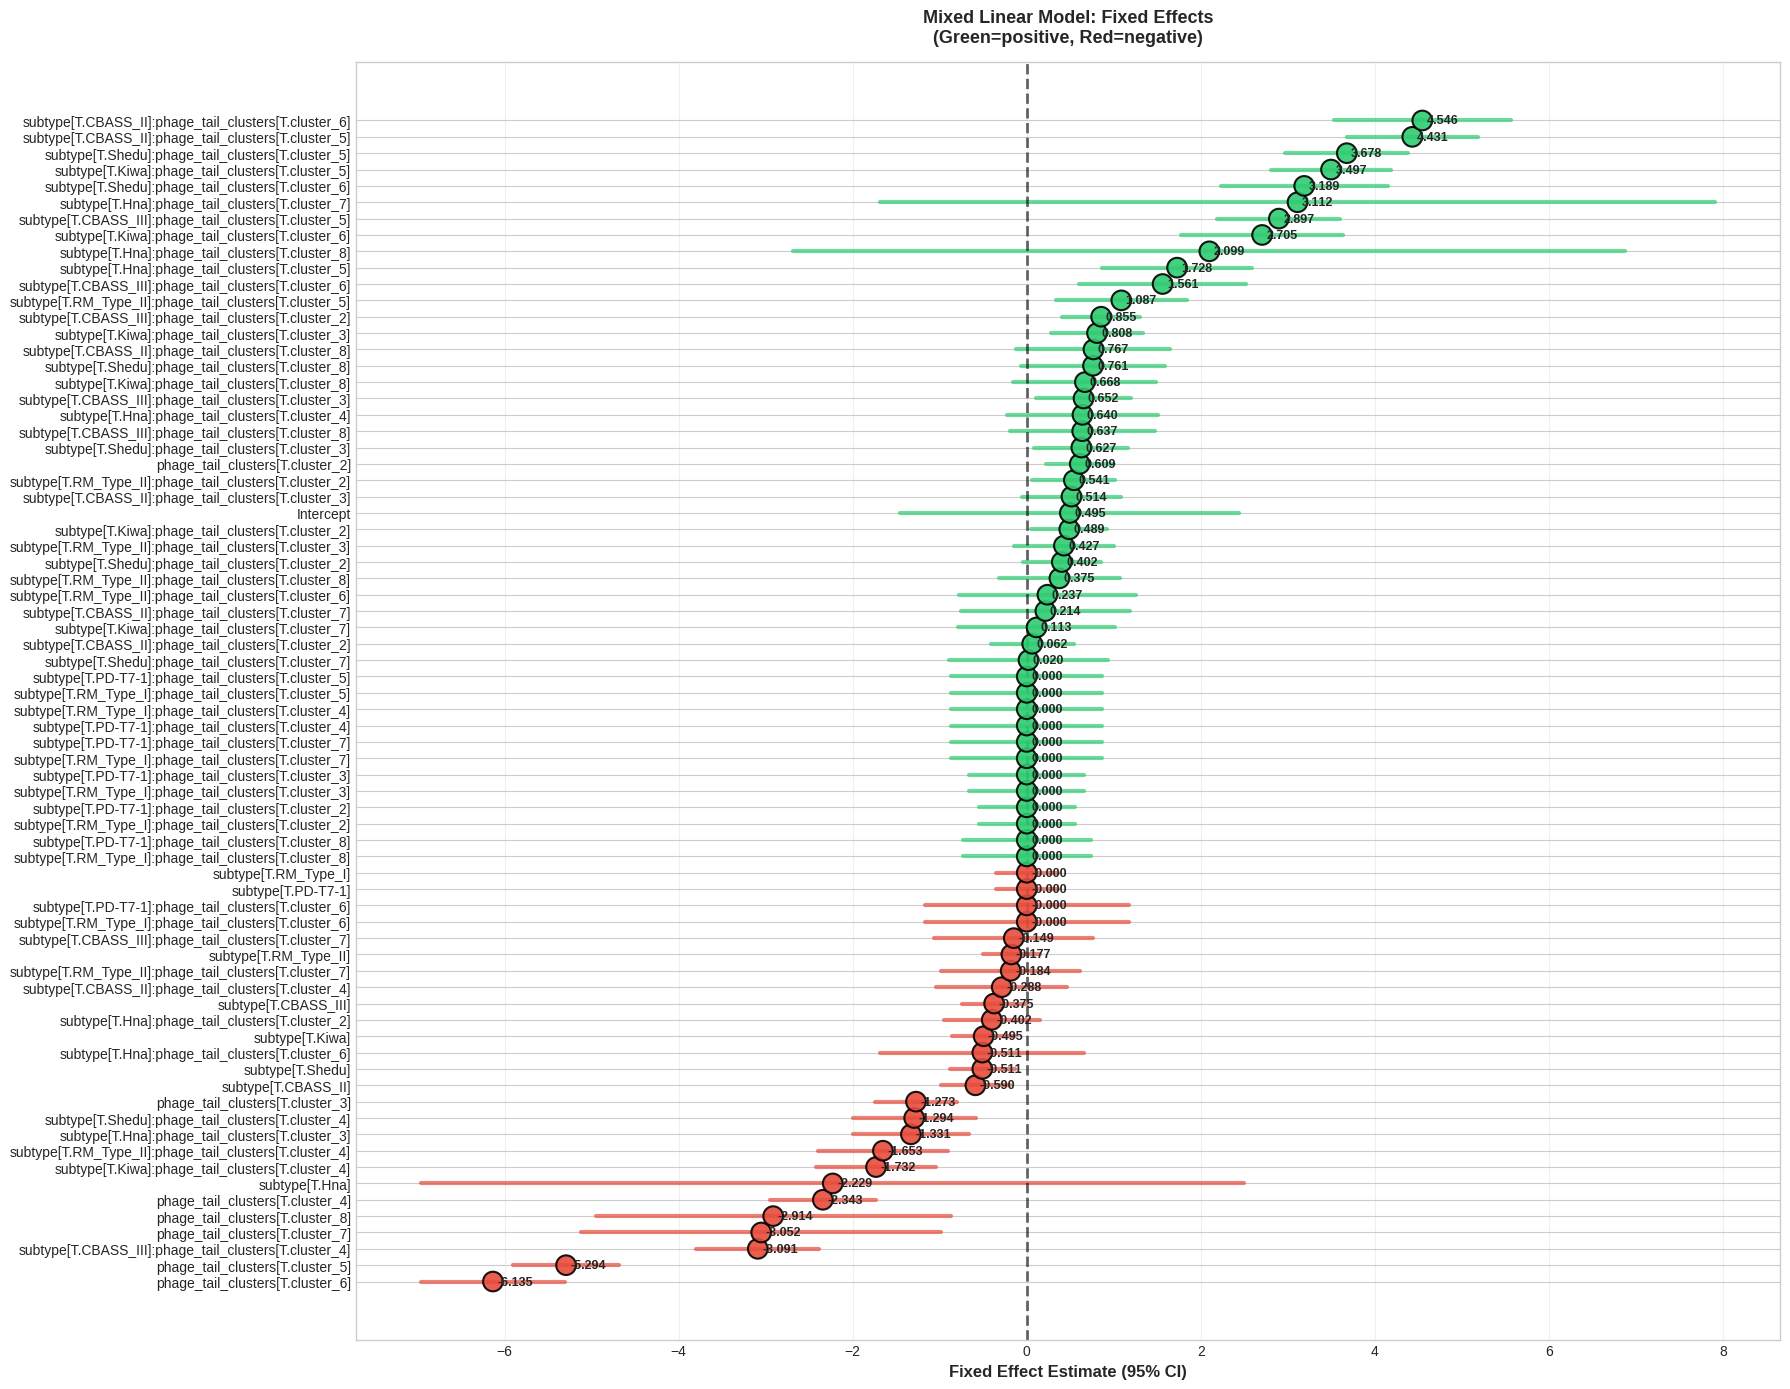

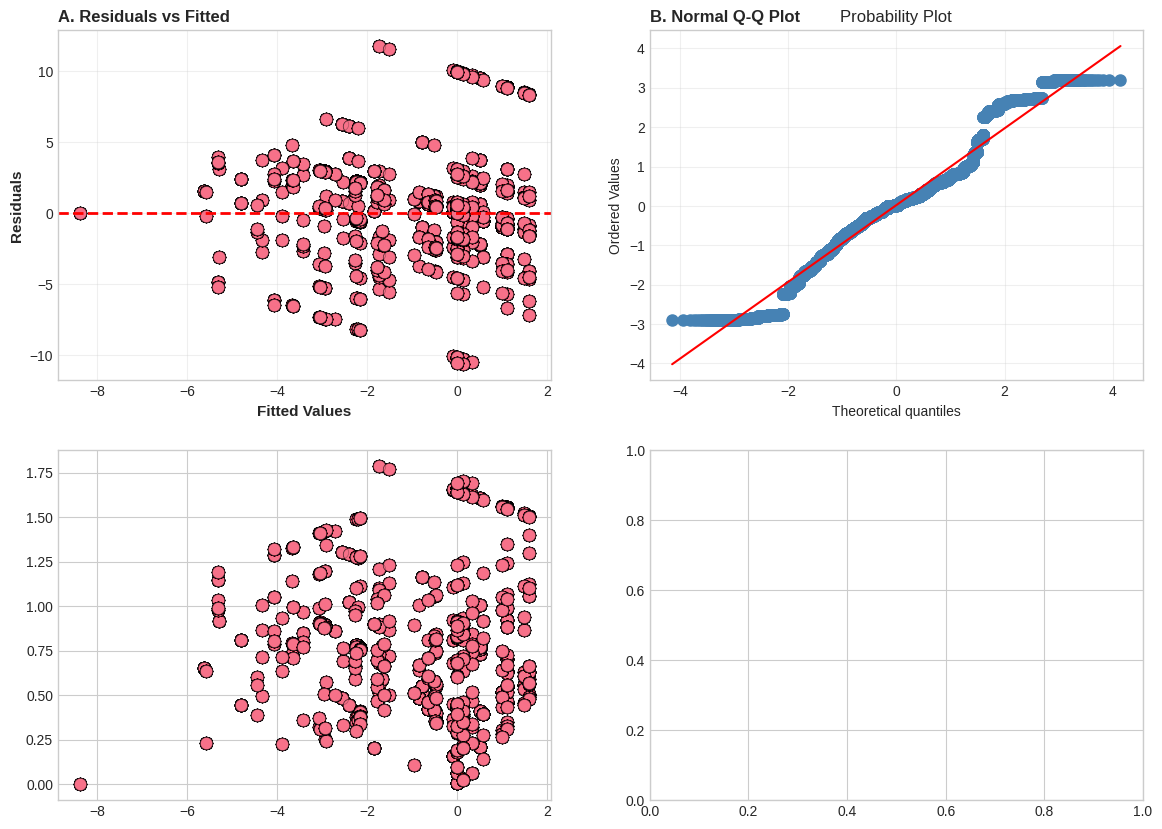

In [71]:
# Copy the code from LMM_Publication_Figures.py into your notebook

# Get predictions
y_pred = result.predict()
y = df['log_EOP']

# Create figures
fig1, ax1 = plot_fixed_effects_forest(result,
                                     save_path='Fig1_forest_plot.png')

fig2, axes2 = plot_model_diagnostics(result, y, y_pred,
                                    save_path='Fig2_diagnostics.png')

fig3, ax3 = plot_variance_components(result,
                                    save_path='Fig3_variance.png')

fig4, ax4 = plot_observed_vs_predicted(y, y_pred, result,
                                      save_path='Fig4_obsVpred.png')

fig5, ax5 = plot_effect_sizes_by_type(result,
                                     save_path='Fig5_effects_by_type.png')